In [1]:
library(jsonlite)
library(rlang)
library(readxl)
library(factoextra)
library(FactoMineR)


Attaching package: ‘rlang’


The following objects are masked from ‘package:jsonlite’:

    flatten, unbox


Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



,Sample,X-1027,X-1095,X-1119,X-1167,X-1173,X-1210,X-1234,X-1256,X-1270,⋯,X-5405,X-5421,X-5438,X-5441,X-5446,X-5494,X-5495,X-5563,X-5578,X-5594
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,0.14,0.13,0.08,0.18,0.00,7.07,0.04,0.00,0.06,⋯,0.06,0.26,0.00,0.27,0.01,0.10,0.05,0.05,0.00,0.00
2,A1BG-AS1,0.00,0.00,0.00,0.00,0.00,3.22,0.00,0.00,0.00,⋯,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,A1CF,1.30,2.83,2.87,3.41,2.96,0.04,9.86,0.49,4.25,⋯,3.00,2.93,0.76,4.39,1.83,10.86,0.49,1.48,1.52,1.85
4,A2LD1,6.45,4.94,11.07,3.28,7.10,4.59,0.00,0.00,6.52,⋯,0.00,5.42,7.52,6.10,3.52,7.30,4.10,8.40,3.16,2.48
5,A2M,0.00,3.69,0.00,0.00,0.02,0.00,0.01,0.00,0.87,⋯,0.00,0.01,0.00,0.00,0.03,0.21,0.00,0.05,0.00,0.00
6,A2ML1,0.00,0.04,0.01,0.09,0.10,0.00,0.00,0.26,0.02,⋯,0.00,0.01,0.04,0.00,0.01,0.01,0.01,0.01,0.03,0.00


,Sample,X-1027,X-1095,X-1119,X-1167,X-1173,X-1210
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,A1BG,0.1890338,0.17632277,0.11103131,0.2387869,0.00000000,3.01256867
2,A1BG-AS1,0.0000000,0.00000000,0.00000000,0.0000000,0.00000000,2.07724300
3,A1CF,1.2016339,1.93734439,1.95233357,2.1407787,1.98550043,0.05658353
4,A2LD1,2.8972404,2.57046293,3.59335377,2.0976108,3.01792191,2.48284828
5,A2M,0.0000000,2.22958792,0.00000000,0.0000000,0.02856915,0.00000000
6,A2ML1,0.0000000,0.05658353,0.01435529,0.1243281,0.13750352,0.00000000


[1]    68 22665

[1] "X-1027" "X-1095" "X-1119"

[1] "A1BG"     "A1BG-AS1" "A1CF"     "A2LD1"    "A2M"

,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1
X-1027,0.1890338,0.000000,1.20163386,2.897240,0.00000000,0.00000000
X-1095,0.1763228,0.000000,1.93734439,2.570463,2.22958792,0.05658353
X-1119,0.1110313,0.000000,1.95233357,3.593354,0.00000000,0.01435529
X-1167,0.2387869,0.000000,2.14077866,2.097611,0.00000000,0.12432814
X-1173,0.0000000,0.000000,1.98550043,3.017922,0.02856915,0.13750352
X-1210,3.0125687,2.077243,0.05658353,2.482848,0.00000000,0.00000000


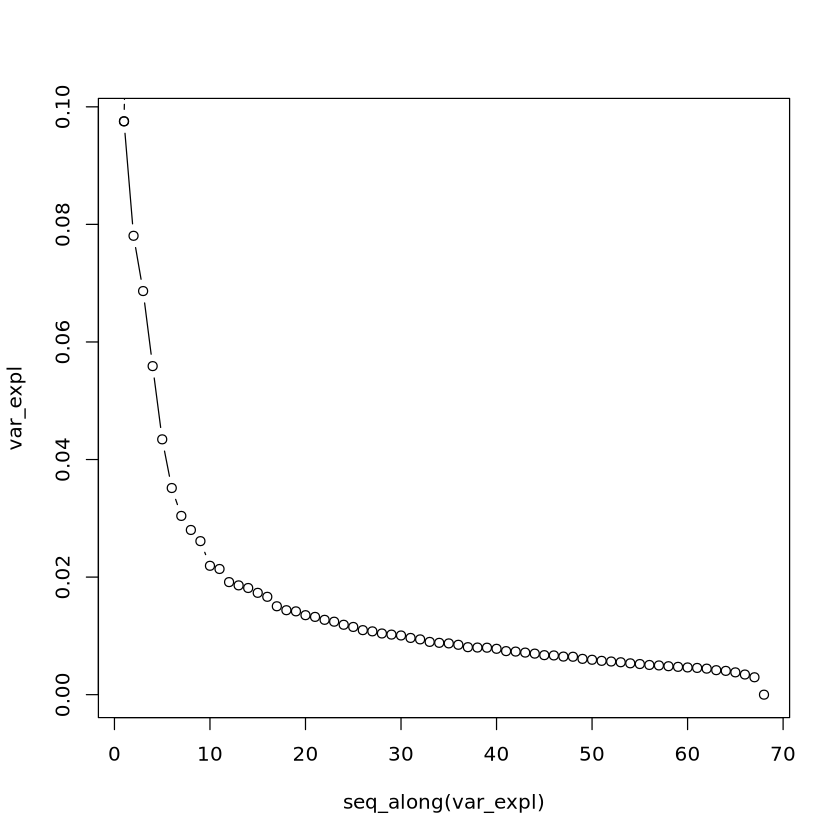

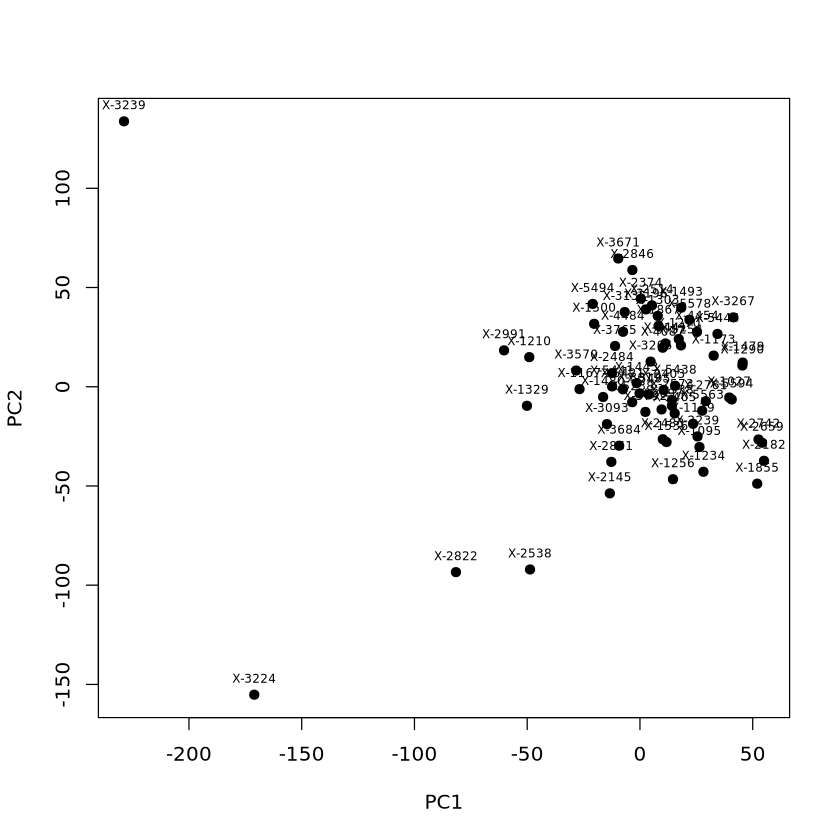

In [2]:
#1. Read the Excel sheet 

data <- read_excel("/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx" , sheet = "RNAseq_fpkm")
data <- as.data.frame(data, check.names = FALSE)



#2.filter samples that have Large intenstine and small intenstine cancer 
Sample_names <- c(
  "Sample","X-0933", "X-1027", "X-1095", "X-1119", "X-1167", "X-1173", "X-1210", "X-1234", "X-1256",
  "X-1270", "X-1290", "X-1303", "X-1329", "X-1441", "X-1443", "X-1479", "X-1480", "X-1493",
  "X-1500", "X-1536", "X-1538", "X-1855", "X-1867", "X-2145", "X-2182", "X-2239", "X-2374",
  "X-2403","X-2483", "X-2484", "X-2514", "X-2538", "X-2573", "X-2659","X-2697", "X-2742", "X-2761", "X-2803",
  "X-2822", "X-2846", "X-2861", "X-2991", "X-3019", "X-3093", "X-3135", "X-3196", "X-3205",
  "X-3224","X-3239", "X-3267", "X-3570", "X-3671", "X-3684", "X-3765", "X-3792", "X-4087", "X-4454",
  "X-4484", "X-5238", "X-5254", "X-5405", "X-5421", "X-5438", "X-5441", "X-5446", "X-5494",
  "X-5495", "X-5563", "X-5578", "X-5594"
)

# filtered_samples1 <- data[, Sample_names]]
# Keep only the names that exist in both lists
existing_samples <- intersect(Sample_names, colnames(data))
filtered_samples2 <- data [, existing_samples]
head(filtered_samples2)


# Which column holds the gene names? (first column of your filtered table)
GENE_COL <- names(filtered_samples2)[1]     # e.g., "Sample"

# All the sample columns = everything except the gene column
num_cols <- setdiff(names(filtered_samples2), GENE_COL)


#3.log transform the data
log_df <- filtered_samples2  #copy
log_df[num_cols] <- log2(log_df[num_cols] + 1)
head(log_df[, c(GENE_COL, num_cols[1:6])])


 #4.tranpose (rows = sample , column = genes)

Gene_col <- names(log_df)[1]
genes <- log_df[[GENE_COL]]

num <- as.matrix(log_df[, setdiff(names(log_df), GENE_COL), drop = FALSE])

X <- t(num)

colnames(X) <- genes

dim(X)                 # expect: <#samples> x <#genes>
head(rownames(X), 3)   # sample IDs like "X-1027", "X-1095", ...
head(colnames(X), 5)   # gene IDs like "A1BG", "A1CF", ...

X[1:6, 1:6]


# 5.(good practice) drop zero-variance genes to avoid divide-by-zero
keep <- apply(X, 2, var) > 0
Xv <- X[, keep, drop = FALSE]

# 6.PCA that centers + scales per gene (column)
pca <- prcomp(Xv, center = TRUE, scale. = TRUE)


var_expl <- (pca$sdev^2) / sum(pca$sdev^2)
cum_expl <- cumsum(var_expl)
plot(seq_along(var_expl), var_expl, type="b")     # scree
lines(seq_along(cum_expl), cum_expl, type="b", lty=2)

plot(pca$x[,1], pca$x[,2], pch=19, xlab="PC1", ylab="PC2")

text(pca$x[,1], pca$x[,2], labels = rownames(pca$x), pos = 3, cex = 0.6)

In [3]:
## Keep only the 51 patients (intersection of your Sample_names and pct$Model),
## then re-do variance filter + PCA on those 51.
## This keeps the SAME intended result, but fixes the matching so it won’t break.

library(readxl)

# -----------------------------
# 0) Read the sheet
# -----------------------------
pct <- read_excel(
  "/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx",
  sheet = "PCT curve metrics"
)
pct <- as.data.frame(pct)

# -----------------------------
# 1) Normalizer (define ONCE)
# -----------------------------
norm_id <- function(x) {
  x <- trimws(as.character(x))
  x <- gsub("[._]", "-", x)      # unify separators
  x <- gsub("\\s+", "", x)       # remove any internal spaces
  toupper(x)                     # ignore case differences
}

# -----------------------------
# 2) Build the 51 IDs to keep
# -----------------------------
requested <- setdiff(Sample_names, "Sample")

req_std   <- norm_id(requested)
model_std <- norm_id(pct$Model)

keep_ids <- intersect(req_std, model_std)     # should be 51
cat("IDs to keep (requested ∩ Model):", length(keep_ids), "\n")

# Optional: quick matching report
matched_count <- sum(req_std %in% model_std)
cat("PCT curve metrics — matched:", matched_count, "of", length(req_std), "\n")

missing_in_model <- setdiff(req_std, model_std)
cat("Missing from Model:", length(missing_in_model), "\n")
# print(missing_in_model)

# -----------------------------
# 3) Subset X by matching rownames (robust, keeps EXACTLY one row per ID)
#    (This avoids your stopifnot failure due to duplicates / formatting)
# -----------------------------
row_ids_raw  <- rownames(X)
row_ids_norm <- norm_id(row_ids_raw)

# Map each keep_id to the FIRST matching row in X (handles possible duplicates safely)
idx <- match(keep_ids, row_ids_norm)

# If any are NA, these IDs were not found among rownames(X)
if (anyNA(idx)) {
  not_found <- keep_ids[is.na(idx)]
  cat("WARNING: IDs in keep_ids not found in rownames(X):", length(not_found), "\n")
  print(head(not_found, 50))
  # If you want to STOP when this happens, uncomment the next line:
  # stop("Some keep_ids were not found in rownames(X). See printed list above.")
}

# Keep only the found ones
idx_ok <- idx[!is.na(idx)]
X51 <- X[idx_ok, , drop = FALSE]
cat("X51 rows kept:", nrow(X51), "\n")

# -----------------------------
# 4) Drop zero-variance genes in the 51 cohort
# -----------------------------
keep_genes <- apply(X51, 2, var) > 0
Xv51 <- X51[, keep_genes, drop = FALSE]

# -----------------------------
# 5) PCA on the 51 only
# -----------------------------
pca51 <- prcomp(Xv51, center = TRUE, scale. = TRUE)



# (optional) variance labels
var_exp51 <- round(100 * (pca51$sdev^2 / sum(pca51$sdev^2)), 1)  

IDs to keep (requested ∩ Model): 51 
PCT curve metrics — matched: 51 of 70 
Missing from Model: 19 
[1] "X-0933"
X51 rows kept: 50 


Total in PCA: 68 
Kept (black): 50 
Filtered-out (gray): 18 


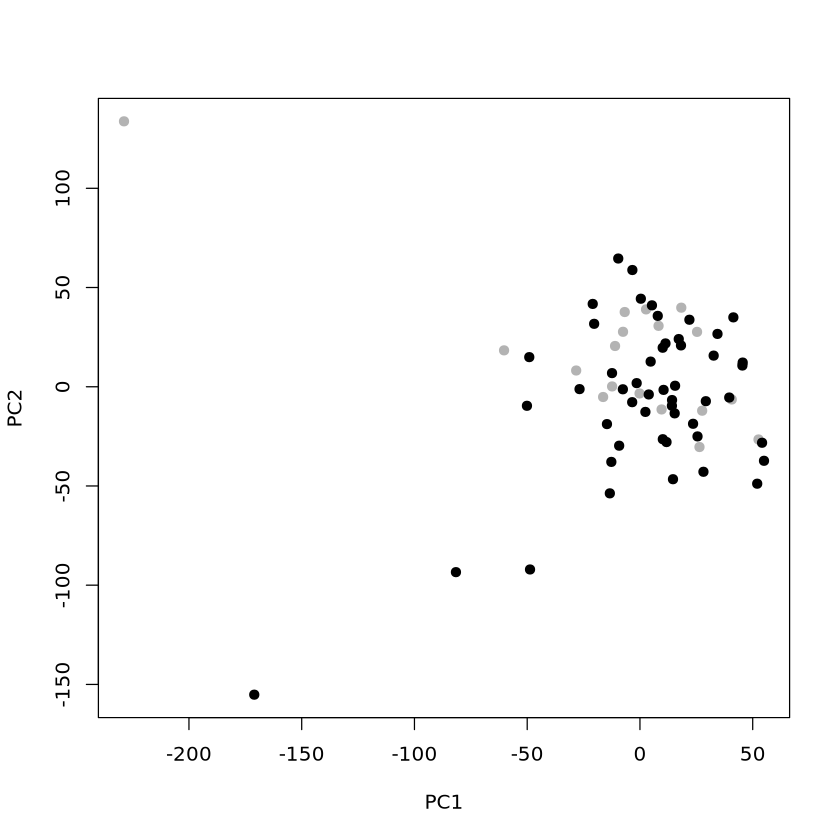

In [4]:
library(readxl)

# ============================================================
# 0) Read expression sheet
# ============================================================
data <- read_excel(
  "/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx",
  sheet = "RNAseq_fpkm"
)
data <- as.data.frame(data, check.names = FALSE)

# ============================================================
# 1) Define the 71 sample names you want in the PCA (columns)
# ============================================================
Sample_names <- c(
  "Sample","X-0933", "X-1027", "X-1095", "X-1119", "X-1167", "X-1173", "X-1210", "X-1234", "X-1256",
  "X-1270", "X-1290", "X-1303", "X-1329", "X-1441", "X-1443", "X-1479", "X-1480", "X-1493",
  "X-1500", "X-1536", "X-1538", "X-1855", "X-1867", "X-2145", "X-2182", "X-2239", "X-2374",
  "X-2403","X-2483", "X-2484", "X-2514", "X-2538", "X-2573", "X-2659","X-2697", "X-2742", "X-2761", "X-2803",
  "X-2822", "X-2846", "X-2861", "X-2991", "X-3019", "X-3093", "X-3135", "X-3196", "X-3205",
  "X-3224","X-3239", "X-3267", "X-3570", "X-3671", "X-3684", "X-3765", "X-3792", "X-4087", "X-4454",
  "X-4484", "X-5238", "X-5254", "X-5405", "X-5421", "X-5438", "X-5441", "X-5446", "X-5494",
  "X-5495", "X-5563", "X-5578", "X-5594"
)

# ============================================================
# 2) Filter to those sample columns
# ============================================================
existing_samples <- intersect(Sample_names, colnames(data))
filtered_samples <- data[, existing_samples, drop = FALSE]

GENE_COL <- names(filtered_samples)[1]
num_cols <- setdiff(names(filtered_samples), GENE_COL)

# ============================================================
# 3) Log2 transform
# ============================================================
log_df <- filtered_samples
log_df[num_cols] <- log2(log_df[num_cols] + 1)

# ============================================================
# 4) Transpose so rows = samples, cols = genes
# ============================================================
genes <- log_df[[GENE_COL]]
num   <- as.matrix(log_df[, num_cols, drop = FALSE])

X <- t(num)                 # samples x genes
colnames(X) <- genes

# ============================================================
# 5) Drop zero-variance genes (based on 71 cohort)
# ============================================================
keep_genes <- apply(X, 2, var) > 0
Xv <- X[, keep_genes, drop = FALSE]

# ============================================================
# 6) PCA on ALL 71 (do not recompute PCA on 51!)
# ============================================================
pca <- prcomp(Xv, center = TRUE, scale. = TRUE)

# ============================================================
# 7) Read PCT curve metrics + build the 51 IDs you want to KEEP
# ============================================================
pct <- read_excel(
  "/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx",
  sheet = "PCT curve metrics"
)
pct <- as.data.frame(pct)

norm_id <- function(x) {
  x <- trimws(as.character(x))
  x <- gsub("[._]", "-", x)
  x <- gsub("\\s+", "", x)
  toupper(x)
}

requested <- setdiff(Sample_names, "Sample")
req_std   <- norm_id(requested)
model_std <- norm_id(pct$Model)

keep_ids <- intersect(req_std, model_std)  # should be 51

# ============================================================
# 8) Determine which PCA points are kept vs filtered-out
# ============================================================
row_ids_norm <- norm_id(rownames(pca$x))
is_keep <- row_ids_norm %in% keep_ids

cat("Total in PCA:", nrow(pca$x), "\n")
cat("Kept (black):", sum(is_keep), "\n")
cat("Filtered-out (gray):", sum(!is_keep), "\n")

# ============================================================
# 9) Plot like your example:
#    - gray first (filtered-out)
#    - black on top (kept)
# ============================================================

par(bg="white")
plot(pca$x[,1], pca$x[,2], type="n", xlab="PC1", ylab="PC2")
points(pca$x[!is_keep,1], pca$x[!is_keep,2], pch=19, col="gray70")
points(pca$x[is_keep,1],  pca$x[is_keep,2],  pch=19, col="black")




In [5]:
sample_map_df <- read.csv("/mnt/lustre/home/nahnsen/nahfo470/mycode/sampleid_map.txt", sep = '\t')
sample_map <- setNames(sample_map_df$NEWID, sample_map_df$OLDID)

counts_path  <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/salmon.merged.gene_counts.tsv"
counts_path_newid  <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/salmon.merged.gene_counts_newid.tsv"

counts30     <- read.delim(counts_path, check.names = FALSE)

new_colnames <- sapply(colnames(counts30), FUN=function(x) { ifelse(x %in% names(sample_map), sample_map[x], x) })
colnames(counts30) <- new_colnames

write.table(counts30, file = counts_path_newid, sep = "\t", quote = FALSE, row.names = FALSE)

'select()' returned 1:many mapping between keys and columns

'select()' returned 1:many mapping between keys and columns

Genes used for projection: 17029



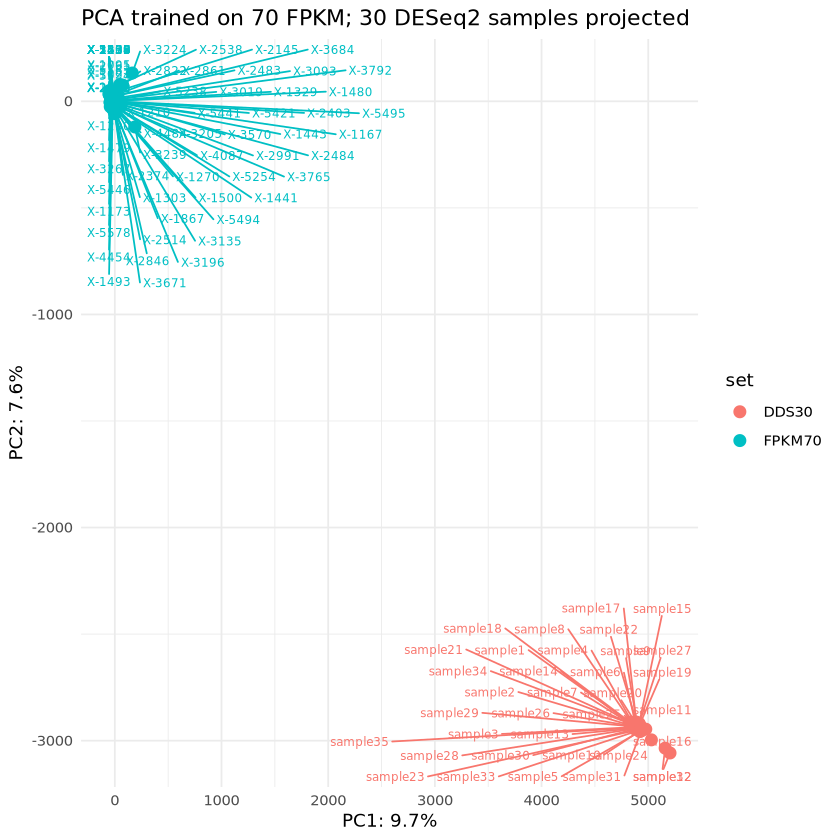

In [6]:
#Second 30 pateints project in to the 70(51) patients list 

## -------- Project 30 DESeq2 samples into the 70-sample PCA --------
suppressPackageStartupMessages({
  library(DESeq2)
  library(org.Hs.eg.db)
  library(AnnotationDbi)
  library(ggplot2)
  library(ggrepel)
})

# 1) Get VST from your dds (DESeq2 cohort)
# (adjust path if needed; skip load() if `dds` is already in memory)
setwd("/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon")
load("deseq2_qc/deseq2.dds.RData")  # loads `dds`
dds <- readRDS("deseq2_qc/deseq2.dds.rename.rds")  # loads `dds`

library(DESeq2)

# this section is for saving the results for python

# If not already loaded:
# load("deseq2_qc/deseq2.dds.RData")  # loads `dds`

vsd <- vst(dds, blind = TRUE)

write.table(assay(vsd),
            file = "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/deseq2_vst.tsv",
            sep = "\t", quote = FALSE, col.names = NA)

# this section is for saving the results for python 


vsd <- vst(dds, blind = TRUE)
mat_deseq <- assay(vsd)  # genes x samples (Ensembl rows)

# 2) Map DESeq2 Ensembl -> HGNC symbols to match FPKM genes (case-insensitive)
ens <- sub("\\.\\d+$", "", rownames(mat_deseq))  # strip version if present
sym <- AnnotationDbi::mapIds(org.Hs.eg.db, keys = ens,
                             keytype = "ENSEMBL", column = "SYMBOL",
                             multiVals = "first")
sym <- toupper(trimws(as.character(sym)))
mat_deseq_sym <- mat_deseq
rownames(mat_deseq_sym) <- sym

# drop NA/empty symbol rows
mat_deseq_sym <- mat_deseq_sym[!is.na(rownames(mat_deseq_sym)) & rownames(mat_deseq_sym)!="", , drop = FALSE]

# collapse duplicate symbols by mean (helper)
collapse_by_mean <- function(m) {
  sp <- split(seq_len(nrow(m)), rownames(m))
  do.call(rbind, lapply(sp, function(ix) {
    if (length(ix) == 1) m[ix, , drop = FALSE] else
      matrix(colMeans(m[ix, , drop = FALSE]), nrow = 1,
             dimnames = list(rownames(m)[ix[1]], colnames(m)))
  }))
}
mat_deseq_sym <- collapse_by_mean(mat_deseq_sym)




# this is section is used for Python 
setwd("/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon")

ens <- rownames(assay(vsd))
ens <- sub("\\.\\d+$","", ens)

sym <- AnnotationDbi::mapIds(org.Hs.eg.db, keys = ens,
                             keytype = "ENSEMBL", column = "SYMBOL",
                             multiVals = "first")

map <- data.frame(ENSEMBL = ens,
                  SYMBOL  = toupper(trimws(sym)),
                  stringsAsFactors = FALSE)
map <- unique(map[!is.na(map$SYMBOL) & map$SYMBOL != "", ])

write.table(map, file = "ensembl_to_symbol.tsv",
            sep = "\t", quote = FALSE, row.names = FALSE)




# 3) Build the NEW data matrix (samples × genes) with exactly the same genes as the PCA
#    Your PCA was trained on Xv (samples × genes), whose column names are symbols from FPKM. ***** # run for the first till Xv
genes_in_pca <- colnames(Xv)

# keep only genes that exist in DESeq2-mapped matrix
genes_use <- intersect(genes_in_pca, rownames(mat_deseq_sym))
message("Genes used for projection: ", length(genes_use))
stopifnot(length(genes_use) > 500)  # relax if needed

# reorder to match PCA feature order, then transpose to samples × genes
Y_new <- t(mat_deseq_sym[genes_in_pca[genes_in_pca %in% genes_use], , drop = FALSE])
# If any genes_in_pca missing in DESeq2, drop them from Xv too for consistent columns:
Xv_restrict <- Xv[, colnames(Y_new), drop = FALSE]

# (Optional) refit PCA on the 70 using the restricted gene set so dimensions match perfectly
# If you prefer to re-use the already-fit 'pca' without refit, skip this block.
pca_fit <- prcomp(Xv_restrict, center = TRUE, scale. = TRUE)

# 4) Project the 30 DESeq2 samples
scores_new <- as.data.frame(predict(pca_fit, newdata = Y_new)[, 1:2, drop = FALSE])
scores_new$sample <- rownames(scores_new)
scores_new$set    <- "DDS30"

# Get the 70 FPKM scores from the (restricted) PCA
scores_train <- as.data.frame(pca_fit$x[, 1:2, drop = FALSE])
scores_train$sample <- rownames(scores_train)
scores_train$set    <- "FPKM70"

# Combine for plotting
scores_all <- rbind(
  setNames(scores_train[, c("sample","PC1","PC2","set")], c("sample","PC1","PC2","set")),
  setNames(scores_new  [, c("sample","PC1","PC2","set")], c("sample","PC1","PC2","set"))
)

var_exp <- round(100 * (pca_fit$sdev^2 / sum(pca_fit$sdev^2)), 1)

# 5) Plot
p <- ggplot(scores_all, aes(PC1, PC2, color = set, label = sample)) +
  geom_point(size = 3) +
  geom_text_repel(size = 2.5, max.overlaps = 200) +
  xlab(paste0("PC1: ", var_exp[1], "%")) +
  ylab(paste0("PC2: ", var_exp[2], "%")) +
  theme_minimal() +
  ggtitle("PCA trained on 70 FPKM; 30 DESeq2 samples projected")

print(p)

# Save


library(ggplot2)

# save as JPG
ggsave("/mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_plotboth.jpg",
       plot = p, width = 8, height = 6, units = "in", dpi = 300)

out_dir <- "/mnt/lustre/home/nahnsen/nahfo470/mycode"
ggsave(file.path(out_dir, "PCA_train70_project30.pdf"), p, width = 8, height = 6)
write.csv(scores_all, file.path(out_dir, "PCA_train70_project30_scores.csv"), row.names = FALSE)


In [7]:
# --- Build gene-lengths from your GTF (server) ---

# install Bioconductor manager if needed
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")

# install needed packages once (will be cached in your home)
for (pkg in c("GenomicFeatures","IRanges","GenomicRanges")) {
  if (!requireNamespace(pkg, quietly = TRUE)) BiocManager::install(pkg, ask = FALSE, update = FALSE)
}

library(GenomicFeatures)

# path to the SAME GTF used in nf-core/rnaseq (adjust if different)
gtf_path <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/ensembl_GRCh38_v114/Homo_sapiens.GRCh38.114.gtf"

# build TxDb (first run may take a few minutes)
txdb <- makeTxDbFromGFF(gtf_path, format = "gtf")

# exons by gene -> reduce overlaps within each gene -> sum widths (bp)
ex_by_gene   <- exonsBy(txdb, by = "gene")
ex_by_gene_r <- reduce(ex_by_gene)
gene_len_vec <- sum(width(ex_by_gene_r))   # named integer vector: names = gene_id

gene_lengths <- data.frame(
  gene_id = names(gene_len_vec),
  length  = as.numeric(gene_len_vec),
  row.names = NULL
)

# quick sanity
cat("Gene lengths computed for:", nrow(gene_lengths), "genes\n")
print(summary(gene_lengths$length))
print(head(gene_lengths, 5))

# save
out_path <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/gene_lengths_from_gtf.tsv"
write.table(gene_lengths, file = out_path, sep = "\t", quote = FALSE, row.names = FALSE)
cat("Saved:", out_path, "\n")

nrow(gene_lengths)          # total number of genes with length
summary(gene_lengths$length) # distribution of lengths


Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK



Gene lengths computed for: 78894 genes
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
     8.0    469.2   1052.0   2483.2   3043.8 348398.0 
          gene_id length
1 ENSG00000000003   4530
2 ENSG00000000005   1476
3 ENSG00000000419   9276
4 ENSG00000000457   6883
5 ENSG00000000460   5970
Saved: /mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/gene_lengths_from_gtf.tsv 


[1] 78894

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
     8.0    469.2   1052.0   2483.2   3043.8 348398.0 

In [8]:

# --- Section B: Compute FPKM for 30 patients

counts_path  <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/salmon.merged.gene_counts_newid.tsv"
lengths_path <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/gene_lengths_from_gtf.tsv"

counts30     <- read.delim(counts_path, check.names = FALSE)
gene_lengths <- read.delim(lengths_path)

# Quick sanity
cat("Counts:", nrow(counts30), "genes x", ncol(counts30)-2, "samples\n")
cat("Lengths:", nrow(gene_lengths), "genes\n")
head(counts30, 3); head(gene_lengths, 3)

# --- Section B: Compute FPKM for 30 patients ---

# 1) Merge counts with gene lengths (keep only overlapping genes)
m <- merge(counts30, gene_lengths, by = "gene_id")

cat("Genes in counts:", nrow(counts30), "\n")
cat("Genes with lengths:", nrow(gene_lengths), "\n")
cat("Genes after merge:", nrow(m), "\n")

# 2) Pull out the numeric count matrix (drop gene_id, gene_name, keep samples)
sample_cols <- setdiff(colnames(m), c("gene_id","gene_name","length"))
count_mat <- as.matrix(m[, sample_cols])
rownames(count_mat) <- m$gene_id

# 3) Library sizes per sample
lib_sizes <- colSums(count_mat, na.rm = TRUE)
cat("Samples:", length(lib_sizes), "\n")
print(head(lib_sizes))

# 4) Compute FPKM
# counts per million (CPM)
cpm <- sweep(count_mat, 2, lib_sizes / 1e6, "/")
# divide by gene length in kb
gene_len_kb <- m$length / 1000
fpkm_mat <- sweep(cpm, 1, gene_len_kb, "/")

# 5) Reattach gene info and save
fpkm <- cbind(
  gene_id   = m$gene_id,
  gene_name = m$gene_name,
  as.data.frame(fpkm_mat, check.names = FALSE)
)

out_path <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/fpkm_30patients.tsv"
write.table(fpkm, file = out_path, sep = "\t", quote = FALSE, row.names = FALSE)
cat("Saved FPKM to:", out_path, "\n")

# 6) Tiny preview
print(head(fpkm[, c("gene_id","gene_name", sample_cols[1:3])], 5))

lib_size <- colSums(counts30[,-c(1,2)])
lib_size["sample1"]

Counts: 78894 genes x 35 samples
Lengths: 78894 genes


,gene_id,gene_name,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,⋯,sample26,sample27,sample28,sample29,sample30,sample31,sample32,sample33,sample34,sample35
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000000003,TSPAN6,407.000,587,788.000,614.000,418.000,117.000,1063,597.000,⋯,2875,643,1719,1629,1219,2407.000,277,668,3176.001,967
2,ENSG00000000005,TNMD,4.000,0,4.000,0.000,9.000,0.000,0,3.000,⋯,9,12,4,5,2,15.000,10,0,14.000,3
3,ENSG00000000419,DPM1,166.001,748,506.998,835.001,252.001,77.001,494,507.998,⋯,2179,1136,1501,1640,912,1123.999,345,952,2057.999,895


,gene_id,length
,<chr>,<int>
1,ENSG00000000003,4530
2,ENSG00000000005,1476
3,ENSG00000000419,9276


Genes in counts: 78894 
Genes with lengths: 78894 
Genes after merge: 78894 
Samples: 35 
 sample1  sample2  sample3  sample4  sample5  sample6 
 2507394  6124524  7748996 11280486  4809542  1532195 
Saved FPKM to: /mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/fpkm_30patients.tsv 
                        gene_id gene_name   sample1   sample2    sample3
ENSG00000000003 ENSG00000000003    TSPAN6 35.832212 21.157656 22.4482546
ENSG00000000005 ENSG00000000005      TNMD  1.080814  0.000000  0.3497262
ENSG00000000419 ENSG00000000419      DPM1  7.137192 13.166444  7.0534253
ENSG00000000457 ENSG00000000457     SCYL3  3.128912  4.127615  3.5060524
ENSG00000000460 ENSG00000000460     FIRRM  3.072988  5.333201  3.8477130


sample1 
2507394

Detected samples: 35 
[1] "sample1" "sample2" "sample3" "sample4" "sample5" "sample6" "sample7"
[8] "sample8"
Duplicate gene symbols to aggregate: 1628 
Matrix dims (samples x genes): 35 x 77266 
Example genes: 5_8S_rRNA, 5S_rRNA, 7SK, A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1, A2ML1, A2ML1-AS1 
Example samples: sample1, sample2, sample3, sample4, sample5 
Any NA in Y_log?  0 
Range of Y_log values:
[1]  0.00000 17.63668


pdf 
  2

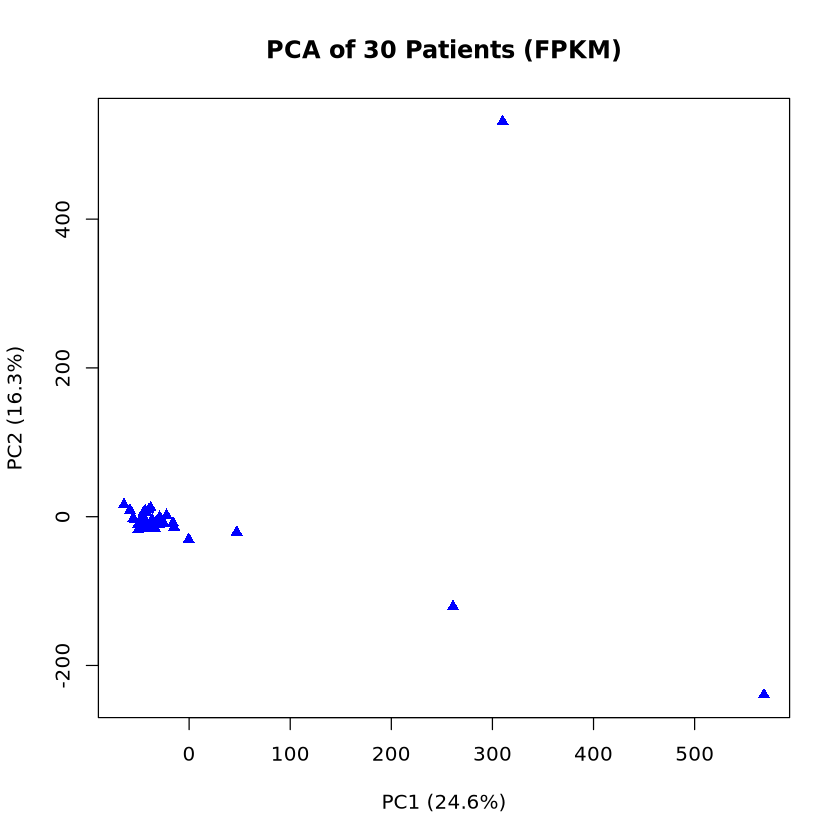

In [9]:

# --- Section C1: prepare 30-patient matrix in gene symbols ---

# 1) Paths
fpkm_path <- "/mnt/lustre/groups/nahnsen/nahfo470/rnaseq/results/star_salmon/fpkm_30patients.tsv"

# 2) Read the 30-patient FPKM
fpkm30 <- read.delim(fpkm_path, check.names = FALSE)

# 3) Identify sample columns
sample_cols <- setdiff(colnames(fpkm30), c("gene_id","gene_name"))
cat("Detected samples:", length(sample_cols), "\n")
print(head(sample_cols, 8))

# 4) Aggregate by gene_name (some symbols may appear more than once)
dup_syms <- sum(duplicated(fpkm30$gene_name))
cat("Duplicate gene symbols to aggregate:", dup_syms, "\n")

# Use base R to aggregate duplicates by MEAN of FPKM (FPKM is already normalized)
fpkm_by_symbol <- aggregate(fpkm30[, sample_cols],
                            by = list(gene_name = fpkm30$gene_name),
                            FUN = mean)

# 5) Build samples × genes matrix
Y <- t(as.matrix(fpkm_by_symbol[, -1]))   # transpose: samples x genes
colnames(Y) <- fpkm_by_symbol$gene_name
rownames(Y) <- rownames(Y)  # already the sample IDs from sample_cols order

cat("Matrix dims (samples x genes):", paste(dim(Y), collapse = " x "), "\n")
cat("Example genes:", paste(colnames(Y)[1:10], collapse = ", "), "\n")
cat("Example samples:", paste(rownames(Y)[1:5], collapse = ", "), "\n")

# 6) Log2 transform to match your 70-sample PCA preprocessing
Y_log <- log2(Y + 1)

# 7) Quick QC
cat("Any NA in Y_log? ", sum(is.na(Y_log)), "\n")
cat("Range of Y_log values:\n")
print(range(Y_log, na.rm = TRUE))




######################################################################################################################

# --- Section C2: PCA on 30 patients only ---

# 1. Drop zero-variance genes
keep <- apply(Y_log, 2, var) > 0
Yv <- Y_log[, keep, drop = FALSE]

# 2. Run PCA
pca30 <- prcomp(Yv, center = TRUE, scale. = TRUE)

# 3. Plot PC1 vs PC2
plot(pca30$x[,1], pca30$x[,2], pch = 17, col = "blue",
     xlab = sprintf("PC1 (%.1f%%)", 100*(pca30$sdev[1]^2/sum(pca30$sdev^2))),
     ylab = sprintf("PC2 (%.1f%%)", 100*(pca30$sdev[2]^2/sum(pca30$sdev^2))),
     main = "PCA of 30 Patients (FPKM)")


# 4. Save as JPG (optional)
jpeg("/mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_30patients.jpg",
     width = 8, height = 6, units = "in", res = 300)
plot(pca30$x[,1], pca30$x[,2], pch = 17, col = "blue",
     xlab = "PC1", ylab = "PC2", main = "PCA of 30 Patients (FPKM)")
dev.off()




Genes in PCA(51): 20360  | Genes in 30: 77266  | Common: 17229 


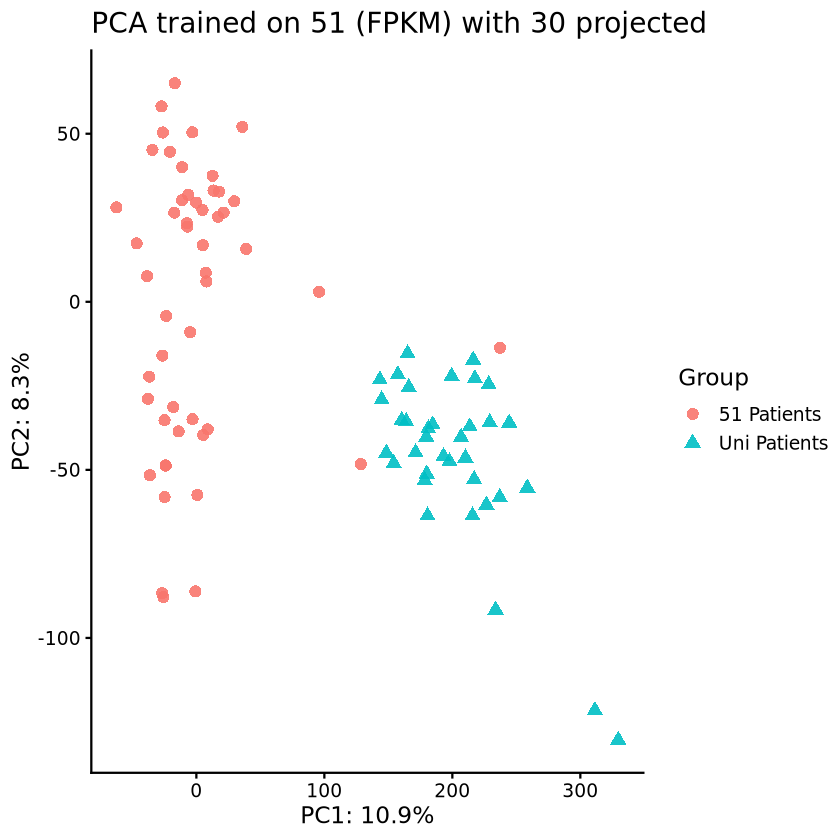

In [10]:

# --- Section C2: Align 30-patient data to 70-patient PCA features ---
genes51 <- colnames(Xv51)
common_genes <- intersect(colnames(Y_log), genes51)
cat("Genes in PCA(51):", length(genes51), 
    " | Genes in 30:", ncol(Y_log), 
    " | Common:", length(common_genes), "\n")

stopifnot(length(common_genes) > 500)   # relax if needed

# 5) Build aligned matrices (samples × common_genes)
Xv51_aligned <- Xv51[, common_genes, drop = FALSE]
Y30_aligned  <- Y_log[, common_genes, drop = FALSE]

# 6) Project 30 onto the PCA(51) using that PCA’s center/scale/rotation
Y30_scaled <- scale(Y30_aligned,
                    center = pca51$center[common_genes],
                    scale  = pca51$scale [common_genes])

Y30_proj <- Y30_scaled %*% pca51$rotation[common_genes, , drop = FALSE]



# --- Section C3: Combine 70- and 30-patient PCA coordinates ---

# Scores for the 51 training samples (PC1–PC2)
scores51 <- as.data.frame(pca51$x[, 1:2, drop = FALSE])
scores51$sample <- rownames(scores51)
scores51$set    <- "51 Patients"

# Scores for the 30 projected samples (PC1–PC2)
scores30 <- as.data.frame(Y30_proj[, 1:2, drop = FALSE])
scores30$sample <- rownames(scores30)
scores30$set    <- "Uni Patients"

scores_all <- rbind(
  setNames(scores51[, c("sample","PC1","PC2","set")], c("sample","PC1","PC2","set")),
  setNames(scores30[, c("sample","PC1","PC2","set")], c("sample","PC1","PC2","set"))
)


# optional: label only the 30s; keep 51 unlabeled
p <- ggplot(scores_all, aes(PC1, PC2, color = set, shape = set)) +
  geom_point(size = 3, alpha = 0.9) +
  scale_shape_manual(values = c("51 Patients" = 16, "Uni Patients" = 17)) +  # 51=circle, 30=triangle
  theme_classic(base_size = 14) +   # white background
  labs(
    title = "PCA trained on 51 (FPKM) with 30 projected",
    x = paste0("PC1: ", var_exp51[1], "%"),
    y = paste0("PC2: ", var_exp51[2], "%"),
    color = "Group", shape = "Group"
  )

print(p)

# Save
out_dir <- "/mnt/lustre/home/nahnsen/nahfo470/mycode"
ggsave(file.path(out_dir, "PCA_train51_project30_noLabels.jpg"), 
       p, width = 8, height = 6, units = "in", dpi = 300)


# (optional) export coordinates
write.csv(scores_all, file.path(out_dir, "PCA_train51_project30_scores.csv"), row.names = FALSE)

These requested IDs were not found in the projected set: smaple20



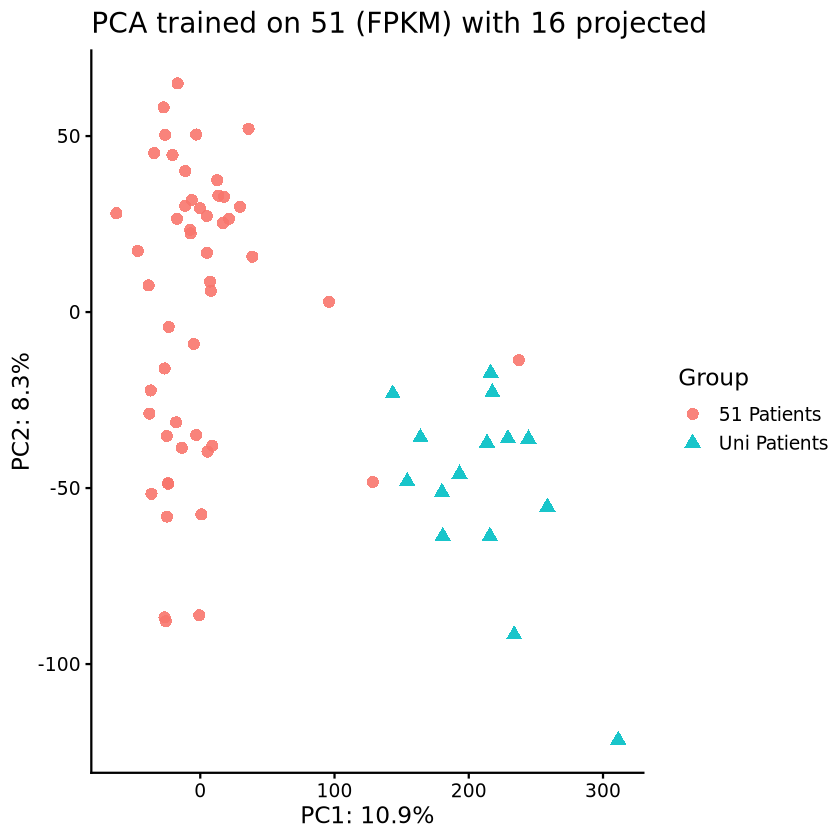

In [11]:
# #filtering 30 patients to 16 . (Before batch correction ) 51 + 16 

# --- define the 16 Uni patients to keep ---


# --- filter the projected set down to those 16 ---

patients_keep <- c(
  "sample9","sample10","sample13","sample14",
  "sample16","sample17","sample19","smaple20",
  "sample21","sample24","sample23","sample26",
  "sample27","sample30","sample31","sample32"
)
scores16 <- subset(scores30, sample %in% patients_keep)

# (optional) sanity check
missing <- setdiff(patients_keep, scores30$sample)
if (length(missing) > 0) {
  message(
    "These requested IDs were not found in the projected set: ",
    paste(missing, collapse = ", ")
  )
}


# --- combine: all 51 + selected 16 ---
scores_51_16 <- rbind(
  setNames(scores51[, c("sample","PC1","PC2","set")], c("sample","PC1","PC2","set")),
  setNames(scores16[, c("sample","PC1","PC2","set")], c("sample","PC1","PC2","set"))
)

# --- plot: 51=circles, 16=triangles; no labels; white background ---
p_51_16 <- ggplot(scores_51_16, aes(PC1, PC2, color = set, shape = set)) +
  geom_point(size = 3, alpha = 0.9) +
  scale_shape_manual(values = c("51 Patients" = 16, "Uni Patients" = 17)) +
  theme_classic(base_size = 14) +
  labs(
    title = "PCA trained on 51 (FPKM) with 16 projected",
    x = paste0("PC1: ", var_exp51[1], "%"),
    y = paste0("PC2: ", var_exp51[2], "%"),
    color = "Group", shape = "Group"
  )

print(p_51_16)

# --- save ---
out_dir <- "/mnt/lustre/home/nahnsen/nahfo470/mycode"
ggsave(file.path(out_dir, "PCA_train51_project16_noLabels.jpg"),
       plot = p_51_16, width = 8, height = 6, units = "in", dpi = 300)
write.csv(scores_51_16, file.path(out_dir, "PCA_train51_project16_scores.csv"), row.names = FALSE)


Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:IRanges’:

    collapse


This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.

Loading required package: genefilter


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


Loading required package: BiocParallel



Found 161 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




Found 161 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data




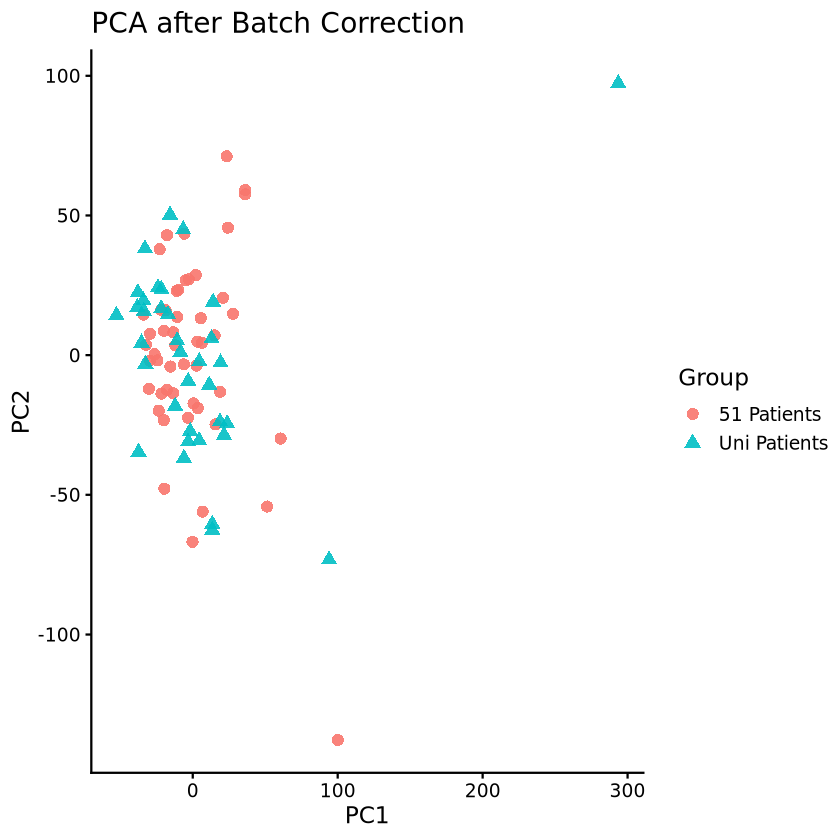

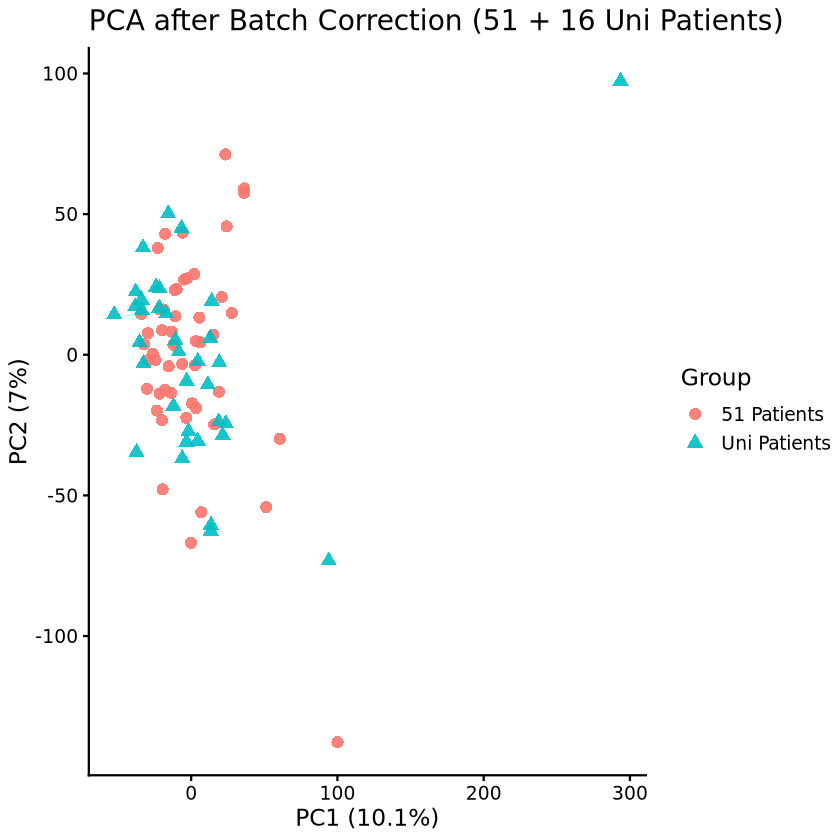

In [12]:
# --- Batch correction with ComBat ---

library(sva)

# 1) Ensure same genes in both sets (51 vs 30)
common_genes <- intersect(colnames(Xv51), colnames(Y_log))
X_common <- Xv51[, common_genes, drop=FALSE]
Y_common <- Y_log[, common_genes, drop=FALSE]

# 2) Combine 51 + 30
mat_combined <- rbind(X_common, Y_common)
batch <- c(rep("51 Patients", nrow(X_common)), rep("Uni Patients", nrow(Y_common)))

# 3) Transpose for ComBat (needs genes x samples)
mat_t <- t(mat_combined)

# 4) Run ComBat
mat_corrected_t <- ComBat(dat = mat_t, batch = batch, par.prior = TRUE, prior.plots = FALSE)

# 5) Transpose back
mat_corrected <- t(mat_corrected_t)

# 6) PCA on corrected data
pca_corrected <- prcomp(mat_corrected, center = TRUE, scale. = TRUE)

# 7) Extract coords for plotting
coords <- as.data.frame(pca_corrected$x[, 1:2])
names(coords)[1:2] <- c("PC1", "PC2")
coords$set <- batch
coords$label <- rownames(coords)
coords$set <- factor(coords$set, levels = c("51 Patients", "Uni Patients"))

library(ggplot2)
library(ggrepel)

# label only Uni Patients (triangles)
unis <- subset(coords, set == "Uni Patients")
p_corrected <- ggplot(coords, aes(PC1, PC2, color = set, shape = set)) +
  geom_point(size = 3, alpha = 0.9) +
  scale_shape_manual(values = c("51 Patients" = 16, "Uni Patients" = 17)) +  # circle vs triangle
  theme_classic(base_size = 14) +  # clean white background
  labs(
    title = "PCA after Batch Correction",
    shape = "Group", color = "Group"
  )

print(p_corrected)

# Save
ggsave("/mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_noLabels.jpg",
       plot = p_corrected, width = 8, height = 6, units = "in", dpi = 300)

#######################################################################################
# Batch Crrection for 51 + 16 

library(sva)

# 1) Ensure same genes in both sets (51 vs 30)
common_genes <- intersect(colnames(Xv51), colnames(Y_log))
X_common <- Xv51[, common_genes, drop=FALSE]
Y_common <- Y_log[, common_genes, drop=FALSE]

# 2) Combine 51 + 30
mat_combined <- rbind(X_common, Y_common)
batch <- c(rep("51 Patients", nrow(X_common)), rep("Uni Patients", nrow(Y_common)))

# 3) Transpose for ComBat (needs genes x samples)
mat_t <- t(mat_combined)

# 4) Run ComBat
mat_corrected_t <- ComBat(dat = mat_t, batch = batch, par.prior = TRUE, prior.plots = FALSE)

# 5) Transpose back
mat_corrected <- t(mat_corrected_t)

# 6) PCA on corrected data
pca_corrected <- prcomp(mat_corrected, center = TRUE, scale. = TRUE)

# 7) Extract coords for plotting
coords <- as.data.frame(pca_corrected$x[, 1:2])
names(coords)[1:2] <- c("PC1", "PC2")
coords$set <- batch
coords$sample <- rownames(coords)
coords$set <- factor(coords$set, levels = c("51 Patients", "Uni Patients"))

# --- Define your 16 Uni Patients ---
patients_keep <- c(
  "sample9","sample10","sample13","sample14",
  "sample16","sample17","sample19","smaple20",
  "sample21","sample24","sample23","sample26",
  "sample27","sample30","sample31","sample32"
)
# --- Keep 51 + only those 16 Uni Patients ---
coords_sub <- subset(coords, set == "51 Patients" | sample %in% patients_keep)

# PCA
pca_corrected <- prcomp(mat_corrected, center = TRUE, scale. = TRUE)

# % variance explained (PC1/PC2)
var_explained <- 100 * (pca_corrected$sdev^2) / sum(pca_corrected$sdev^2)
pc1_var <- round(var_explained[1], 1)
pc2_var <- round(var_explained[2], 1)

# coords
coords <- as.data.frame(pca_corrected$x[, 1:2])
names(coords)[1:2] <- c("PC1", "PC2")
coords$set <- batch
coords$label <- rownames(coords)
coords$set <- factor(coords$set, levels = c("51 Patients", "Uni Patients"))

p_corrected <- ggplot(coords, aes(PC1, PC2, color = set, shape = set)) +
  geom_point(size = 3, alpha = 0.9) +
  scale_shape_manual(values = c("51 Patients" = 16, "Uni Patients" = 17)) +

  # lock padding so it won't change with label length
  scale_x_continuous(expand = expansion(mult = 0.05)) +
  scale_y_continuous(expand = expansion(mult = 0.05)) +

  theme_classic(base_size = 14) +

  # lock margins (prevents plot shrinking when labels get longer)
  theme(
    plot.margin = unit(c(5.5, 5.5, 5.5, 5.5), "pt")
  ) +

  labs(
    title = "PCA after Batch Correction (51 + 16 Uni Patients)",
    x = paste0("PC1 (", pc1_var, "%)"),
    y = paste0("PC2 (", pc2_var, "%)"),
    shape = "Group", color = "Group"
  )

print(p_corrected)

ggsave(
  "/mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16.jpg",
  plot = p_corrected, width = 8, height = 6, units = "in", dpi = 300,
  limitsize = FALSE
)



In [13]:
# ---- EXPORT FOR PYTHON ----
out_dir <- "/mnt/lustre/home/nahnsen/nahfo470/mycode"

# 1️⃣ Batch-corrected expression (samples × genes)
write.csv(mat_corrected, file.path(out_dir, "combat_corrected_matrix.csv"))

# 2️⃣ PCA outputs
write.csv(pca_corrected$x,        file.path(out_dir, "pca_scores.csv"))      # samples × PCs
write.csv(pca_corrected$rotation, file.path(out_dir, "pca_loadings.csv"))    # genes × PCs
write.csv(data.frame(center=pca_corrected$center), file.path(out_dir, "pca_center.csv"))
write.csv(data.frame(scale=pca_corrected$scale),   file.path(out_dir, "pca_scale.csv"))
write.csv(data.frame(sdev=pca_corrected$sdev),     file.path(out_dir, "pca_sdev.csv"))

# 3️⃣ Variance explained
var_expl <- (pca_corrected$sdev^2)/sum(pca_corrected$sdev^2)
write.csv(data.frame(var_explained=var_expl),
          file.path(out_dir, "pca_variance_explained.csv"), row.names=FALSE)

# 4️⃣ Metadata (sample IDs + batch labels)
write.csv(data.frame(sample=rownames(mat_corrected), batch=batch),
          file.path(out_dir, "metadata_samples.csv"), row.names=FALSE)


In [14]:
# Color the PCA-batch correction

In [15]:
suppressPackageStartupMessages({
  library(readxl)
  library(ggplot2)
  library(sva)
})

# -------------------- Helpers --------------------
norm_id <- function(x) gsub("[._ ]","-", trimws(as.character(x)))

canon_resp_generic <- function(x){
  y <- toupper(trimws(as.character(x)))
  y[y %in% c("", "NA", "N/A", "1")] <- NA
  y <- sub("^COMPLETE.*","CR", y)
  y <- sub("^PARTIAL.*","PR", y)
  y <- sub("^STABLE.*","SD", y)
  y <- sub("^PROGRESS.*","PD", y)
  y[grepl("->\\s*PD", y)] <- "PD"
  y[grepl("->\\s*PR", y)] <- "PR"
  y[grepl("->\\s*SD", y)] <- "SD"
  y[!(y %in% c("CR","PR","SD","PD"))] <- NA
  y
}

apply_overrides_51 <- function(raw_vec){
  resp_norm <- toupper(gsub("[[:space:].]", "", as.character(raw_vec)))
  out <- canon_resp_generic(raw_vec)
  out[resp_norm == "SD-->PD"]    <- "PD"
  out[resp_norm == "SD-->-->PD"] <- "SD"
  out[resp_norm == "PR-->PD"]    <- "PD"
  out[resp_norm == "PR-->-->PD"] <- "PR"
  out[!(out %in% c("CR","PR","SD","PD"))] <- NA
  out
}

# Build a matcher from keyword patterns (ALL must be present)
make_treatment_matcher <- function(patterns){
  patterns <- tolower(patterns)
  function(txt_vec){
    t <- tolower(ifelse(is.na(txt_vec), "", as.character(txt_vec)))
    # all patterns must match somewhere
    Reduce(`&`, lapply(patterns, function(p) grepl(p, t, perl = TRUE)))
  }
}

# -------------------- MAIN runner --------------------
run_treatment_pca <- function(
  TREAT_NAME,
  TREAT_PATTERNS,
  coords_sub,          # your PCA coords after batch correction (51 + 16 or 51 + 30)
  out_dir = "/mnt/lustre/home/nahnsen/nahfo470/mycode",
  patient_list_xlsx = "/mnt/lustre/home/nahnsen/nahfo470/mycode/Patient-List.xlsx",
  p30_xlsx = "/mnt/lustre/home/nahnsen/nahfo470/mycode/30 Patients Data.xlsx",
  sheet_51 = "PCT curve metrics",
  sheet_30 = 1
){
  match_treat <- make_treatment_matcher(TREAT_PATTERNS)

  # ---------- 51 cohort ----------
  pct <- read_excel(patient_list_xlsx, sheet = sheet_51) |> as.data.frame()
  resp_col_51  <- grep("^\\s*Response\\s*Categor", names(pct), ignore.case = TRUE, value = TRUE)
  treat_col_51 <- grep("^\\s*(Treatment|Therapy|Regimen)\\s*$", names(pct), ignore.case = TRUE, value = TRUE)
  if (length(resp_col_51) == 0) stop("Response column not found in 'PCT curve metrics'.")
  if (length(treat_col_51) == 0) stop("Treatment column not found in 'PCT curve metrics'.")

  pct$Model_std <- norm_id(pct$Model)
  pct$TrtMatch  <- match_treat(pct[[treat_col_51[1]]])
  pct$Response4 <- apply_overrides_51(pct[[resp_col_51[1]]])

  resp51_map <- tapply(seq_len(nrow(pct)), pct$Model_std, function(ii){
    jj <- ii[pct$TrtMatch[ii]]
    if (!length(jj)) return(NA_character_)
    rr <- pct$Response4[jj]; rr <- rr[!is.na(rr)]
    if (length(rr)) rr[1] else NA_character_
  })

  # ---------- 30 cohort ----------
  p30 <- read_excel(p30_xlsx, sheet = sheet_30) |> as.data.frame()
  names(p30) <- trimws(names(p30))

  id_col_30 <- "NewID"
  b1 <- p30[["Behandlung 1"]]; b2 <- p30[["Behandlung 2"]]
  c1 <- p30[["Cluster1"]];     c2 <- p30[["Cluster 2"]]
  if (is.null(b1) || is.null(b2) || is.null(c1) || is.null(c2)) {
    stop("Expected 'Behandlung 1/2' and 'Cluster1'/'Cluster 2' in 30 Patients Data.xlsx.")
  }

  p30$ID_std <- norm_id(p30[[id_col_30]])
  m1 <- match_treat(b1)
  m2 <- match_treat(b2)

  resp30_vec <- rep(NA_character_, nrow(p30))
  resp30_vec[m1 & !m2] <- c1[m1 & !m2]
  resp30_vec[m2 & !m1] <- c2[m2 & !m1]
  resp30_vec[m1 &  m2] <- c1[m1 &  m2]

  resp30_vec <- canon_resp_generic(resp30_vec)
  resp30_map <- setNames(resp30_vec, p30$ID_std)

  # ---------- merge onto coords_sub ----------
  df <- coords_sub
  if (!"sample" %in% names(df)) df$sample <- rownames(df)
  df$ID_std <- norm_id(df$sample)

  is51  <- df$set == "51 Patients"
  isUni <- df$set == "Uni Patients"

  df$ResponseUnified <- NA_character_
  df$ResponseUnified[is51]  <- unname(resp51_map[df$ID_std[is51]])
  df$ResponseUnified[isUni] <- unname(resp30_map[df$ID_std[isUni]])

  df$ResponseLegend <- ifelse(is.na(df$ResponseUnified),
                              "Not on this treatment",
                              df$ResponseUnified)
  resp_levels <- c("CR","PR","SD","PD","Not on this treatment")
  df$ResponseLegend <- factor(df$ResponseLegend, levels = resp_levels)

  shape_map <- c("51 Patients" = 16, "Uni Patients" = 17)
  pal_resp <- c(
    CR = "#deeb27",
    PR = "#1f77b4",
    SD = "#2ca02c",
    PD = "#d62728",
    "Not on this treatment" = "grey80"
  )

  p_col <- ggplot(df, aes(PC1, PC2)) +
    geom_point(aes(color = ResponseLegend, shape = set),
               size = 3, alpha = 0.95, show.legend = TRUE) +
    scale_shape_manual(values = shape_map, name = "Group") +
    scale_color_manual(values = pal_resp,
                       breaks = resp_levels,
                       drop = FALSE,
                       name = "Response") +
    guides(
      color = guide_legend(override.aes = list(shape = 16, size = 4)),
      shape = guide_legend(override.aes = list(size = 4))
    ) +
    theme_classic(base_size = 14) +
    theme(
      plot.title.position = "panel",
      plot.title = element_text(size = 11, hjust = 0.5),
      legend.position = "right",
      legend.title = element_text(size = 11),
      legend.text  = element_text(size = 10),
      panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.8),
      axis.line    = element_blank()
    ) +
    labs(
      title = paste0("PCA after Batch Correction (51 + selected 16) — ", TREAT_NAME),
      x = "PC1", y = "PC2"
    )

  print(p_col)

  safe_name <- gsub("[^A-Za-z0-9]+", "_", toupper(TREAT_NAME))
  out_plot <- file.path(out_dir, paste0("PCA_batchcorrect_51plus16_", safe_name, ".jpg"))
  out_csv  <- file.path(out_dir, paste0("PCA_", safe_name, "_colored.csv"))

  ggsave(out_plot, plot = p_col, width = 9, height = 6, units = "in", dpi = 300, bg = "white")
  write.csv(df, out_csv, row.names = FALSE)

  cat("51-sheet rows matching treatment:", sum(pct$TrtMatch, na.rm=TRUE), "\n")
  cat("Colored counts (CR/PR/SD/PD) across both cohorts:\n")
  print(table(df$ResponseUnified, useNA = "ifany"))
  cat("\nColored (non-NA) by cohort:\n")
  print(with(df, table(set, !is.na(ResponseUnified))))

  invisible(list(plot = p_col, data = df))
}


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + Avastin' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + Avastin' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + Avastin' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + Avastin' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   SD <NA> 
   3    1   61 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    11    4


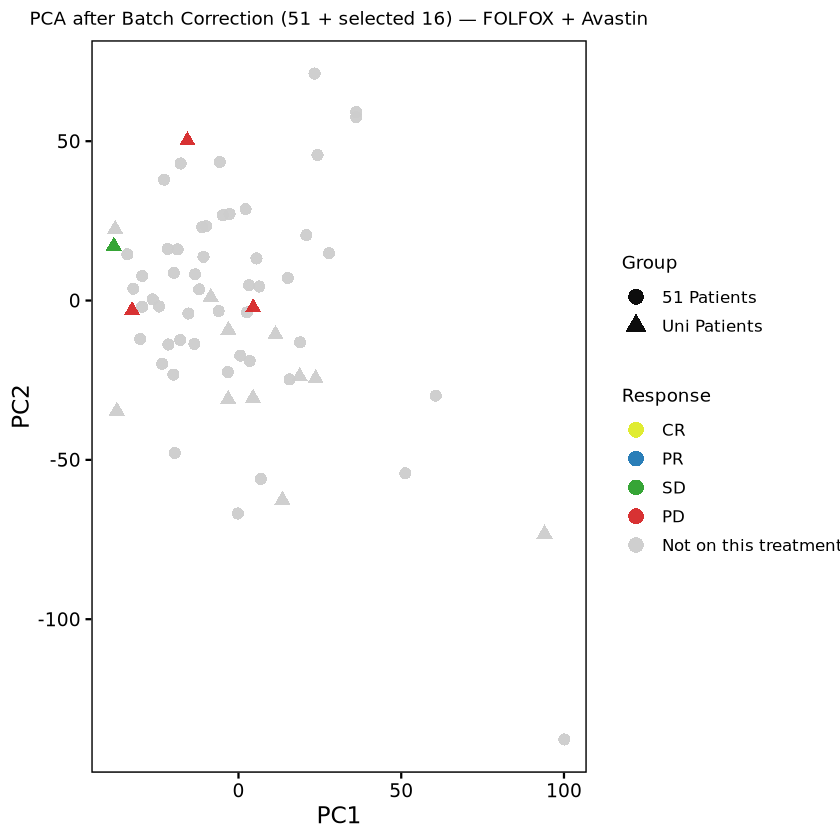

In [16]:
# -------------------- Example call (your current one) --------------------
# Uses your existing coords_sub object (already created earlier)
run_treatment_pca(
  TREAT_NAME     = "FOLFOX + Avastin",
  TREAT_PATTERNS = c("\\bm?folfox\\w*\\b", "\\b(avastin|bevacizumab)\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + Avastin' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + Avastin' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + Avastin' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + Avastin' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correcti

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   5   60 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    10    5


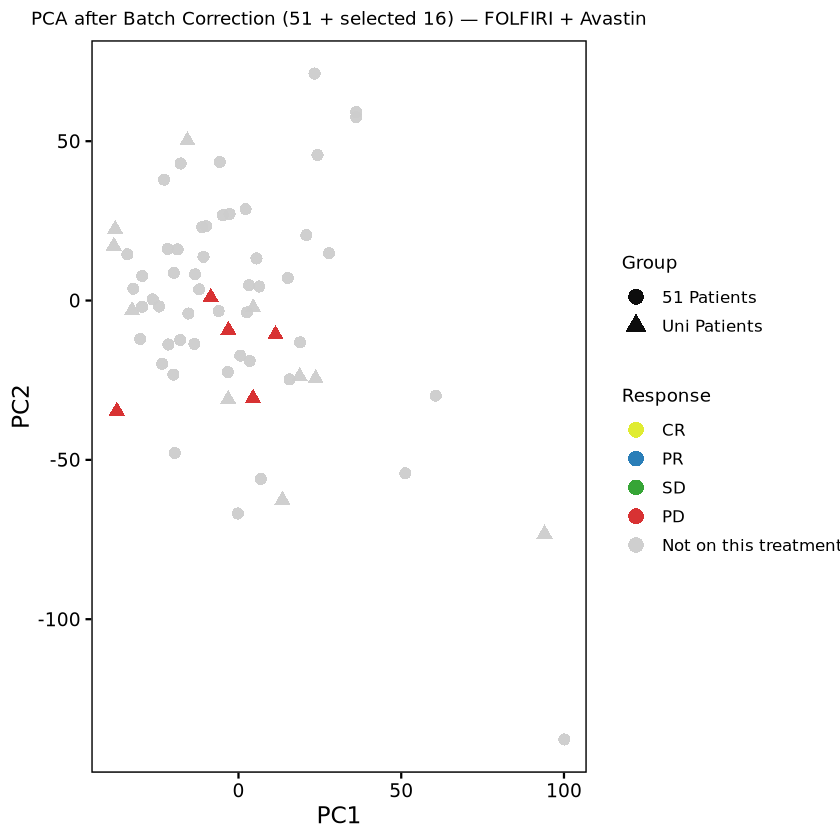

In [17]:
run_treatment_pca(
  TREAT_NAME     = "FOLFIRI + Avastin",
  TREAT_PATTERNS = c("\\bfolfiri\\w*\\b", "\\b(avastin|bevacizumab)\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AFLIBERCEPT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AFLIBERCEPT' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AFLIBERCEPT' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AFLIBERCEPT' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA afte

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


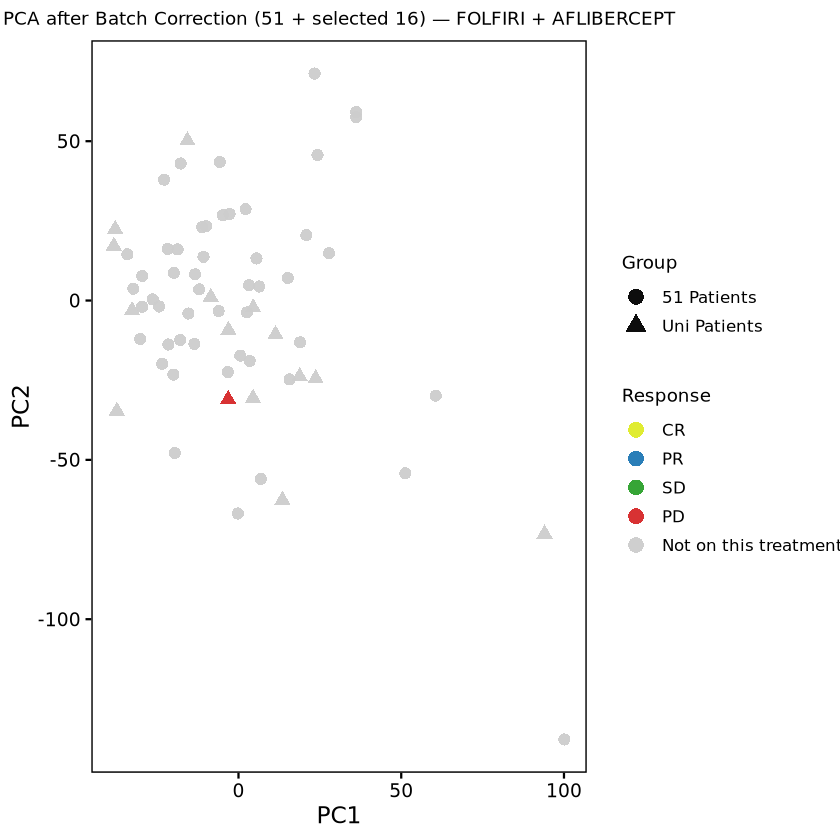

In [18]:
run_treatment_pca(
  TREAT_NAME     = "FOLFIRI + AFLIBERCEPT",
  TREAT_PATTERNS = c("\\bfolfiri\\w*\\b", "\\baflibercep\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIO + CHEMOTHERAPY' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIO + CHEMOTHERAPY' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIO + CHEMOTHERAPY' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIO + CHEMOTHERAPY' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Ba

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


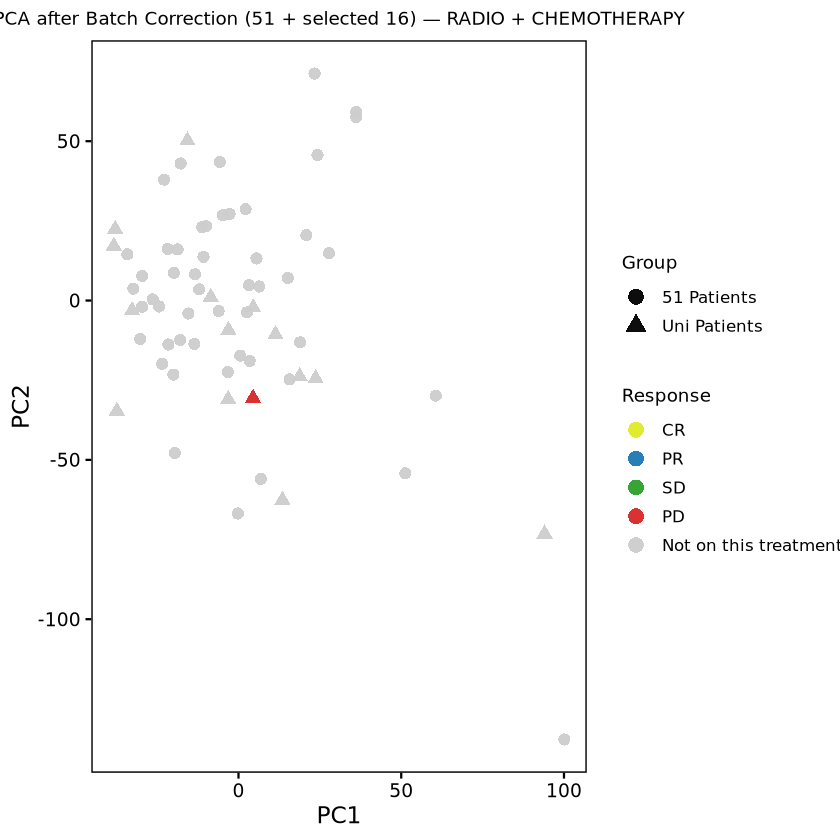

In [19]:
run_treatment_pca(
  TREAT_NAME     = "RADIO + CHEMOTHERAPY",
  TREAT_PATTERNS = c("\\b(radio|radiotherap|radiotherapie|rt)\\w*\\b", "\\b(chemo|chemotherap|chemotherapie)\\w*\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF' in 'mbc

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   2   63 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    13    2


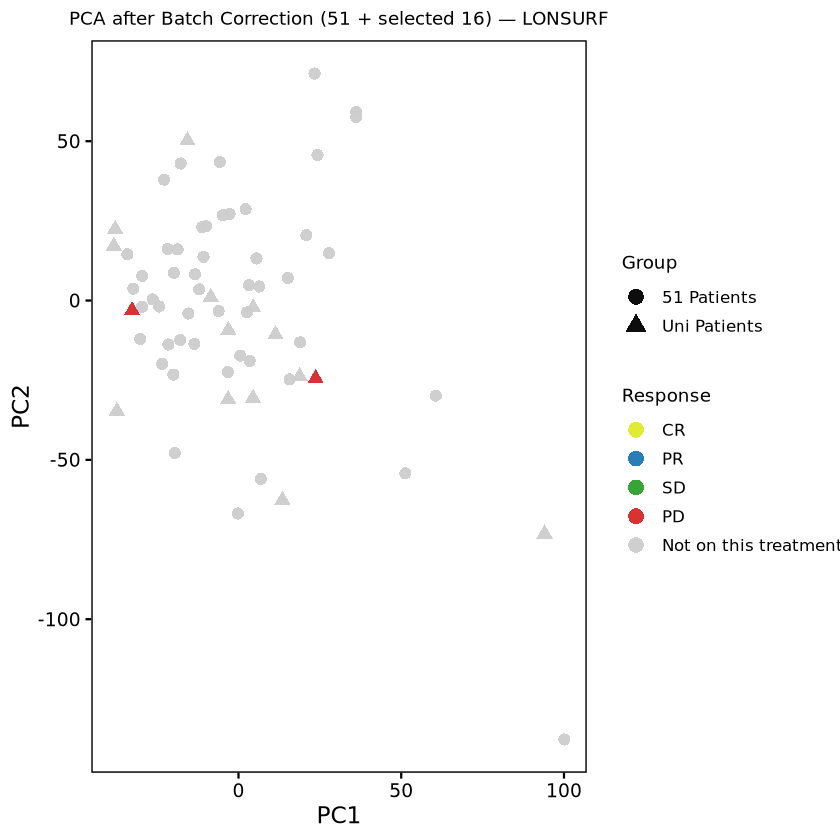

In [20]:
run_treatment_pca(
  TREAT_NAME     = "LONSURF",
  TREAT_PATTERNS = c("^\\s*(lonsurf|trifluridine|tipiracil)\\s*$"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA afte

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   SD <NA> 
   1    1   63 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    13    2


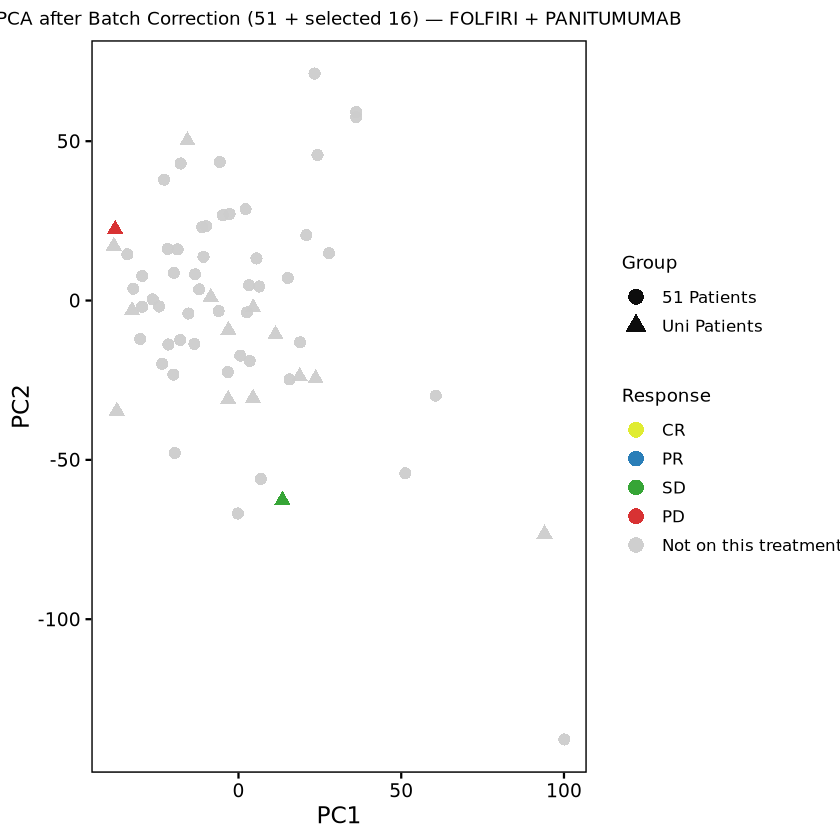

In [21]:

run_treatment_pca(
  TREAT_NAME = "FOLFIRI + PANITUMUMAB",
  TREAT_PATTERNS = c("folfiri", "panitumumab"),
  coords_sub = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — XELOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — XELOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — XELOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — XELOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 +

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


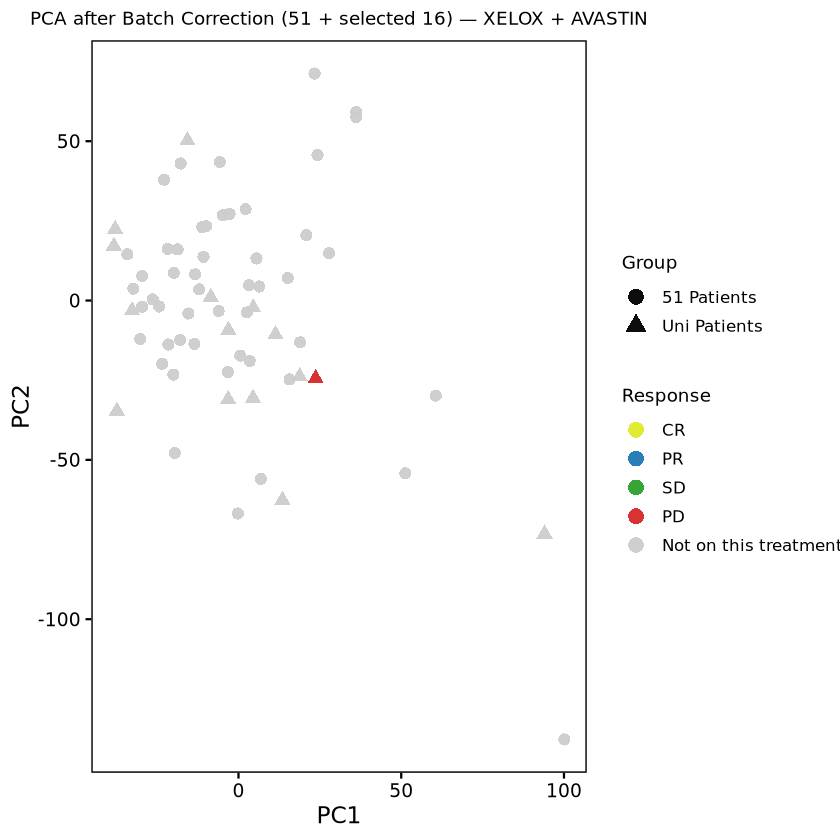

In [22]:
run_treatment_pca(
  TREAT_NAME     = "XELOX + AVASTIN",
  TREAT_PATTERNS = c("\\b(xelox|capeox)\\b", "\\b(avastin|bevacizumab)\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Ba

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


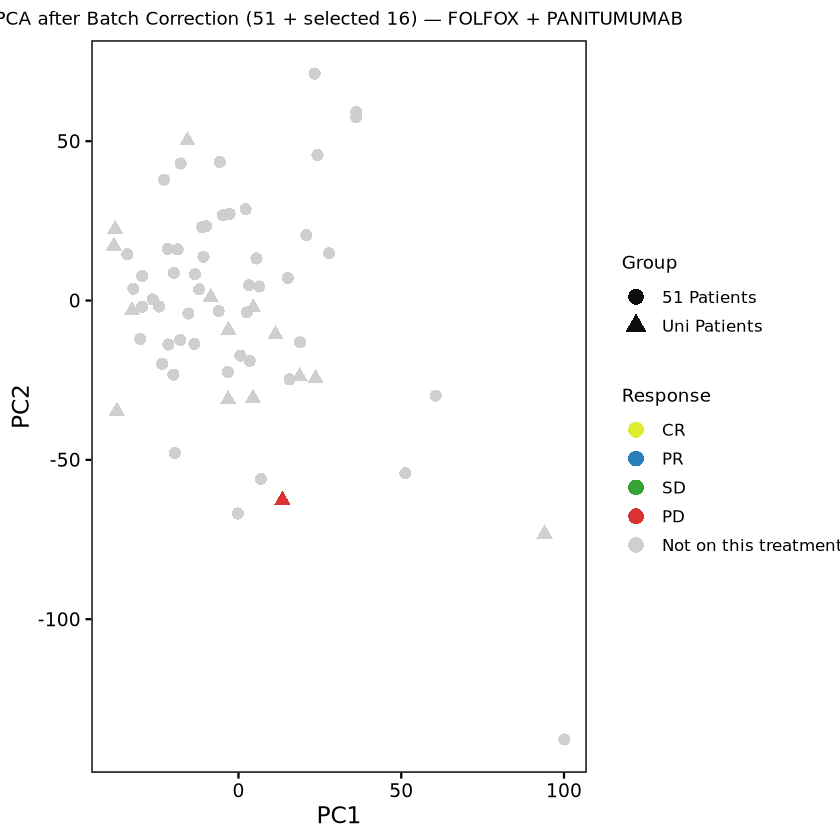

In [23]:
run_treatment_pca(
  TREAT_NAME     = "FOLFOX + PANITUMUMAB",
  TREAT_PATTERNS = c("\\bm?folfox\\w*\\b", "\\bpanitumumab\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LONSURF + PANITUMUMAB' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA afte

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


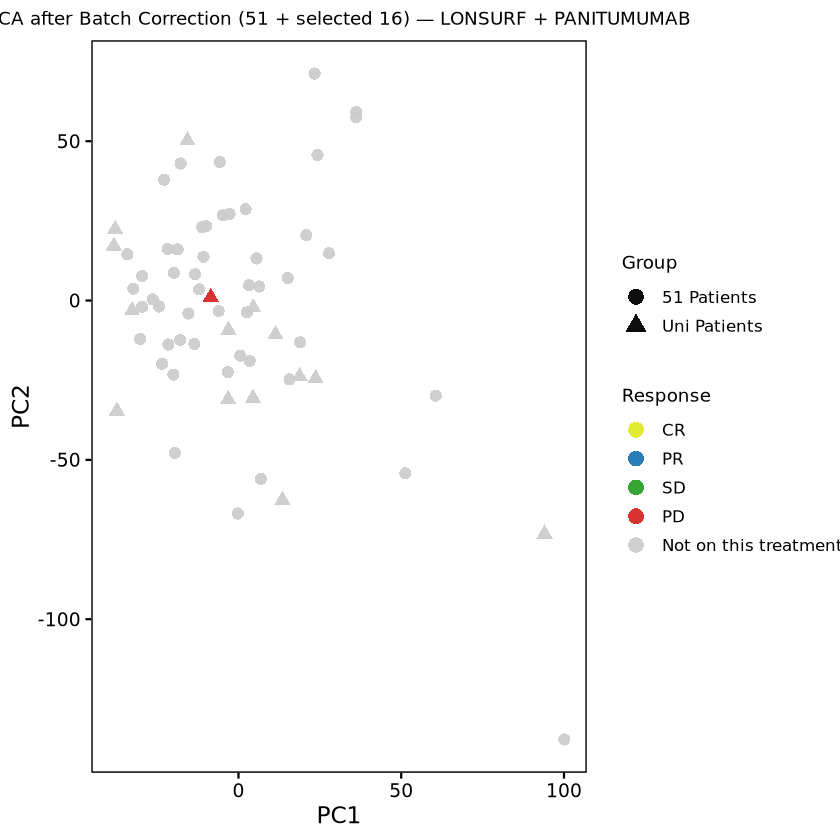

In [24]:
run_treatment_pca(
  TREAT_NAME     = "LONSURF + PANITUMUMAB",
  TREAT_PATTERNS = c("\\b(lonsurf|trifluridine|tipiracil)\\b", "\\bpanitumumab\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX' in 'mbcsToSb

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


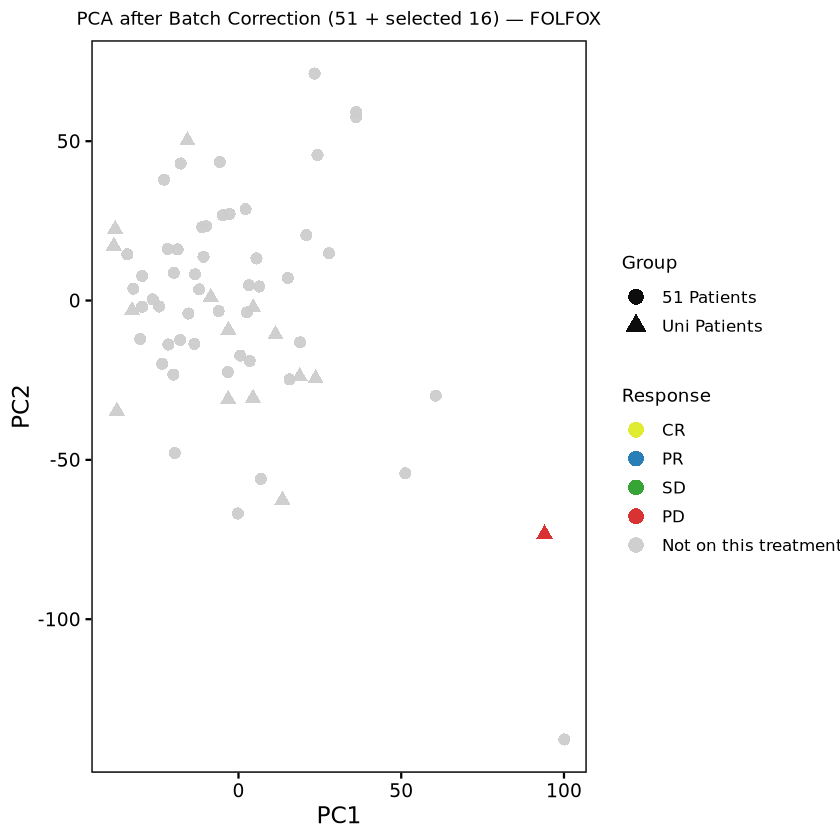

In [25]:
run_treatment_pca(
  TREAT_NAME     = "FOLFOX",
  TREAT_PATTERNS = c("^\\s*folfox\\s*$"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CHIRURGISCHE BEHANDLUNG (OP)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CHIRURGISCHE BEHANDLUNG (OP)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CHIRURGISCHE BEHANDLUNG (OP)' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CHIRURGISCHE BEHANDLUNG (OP)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“con

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PR <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


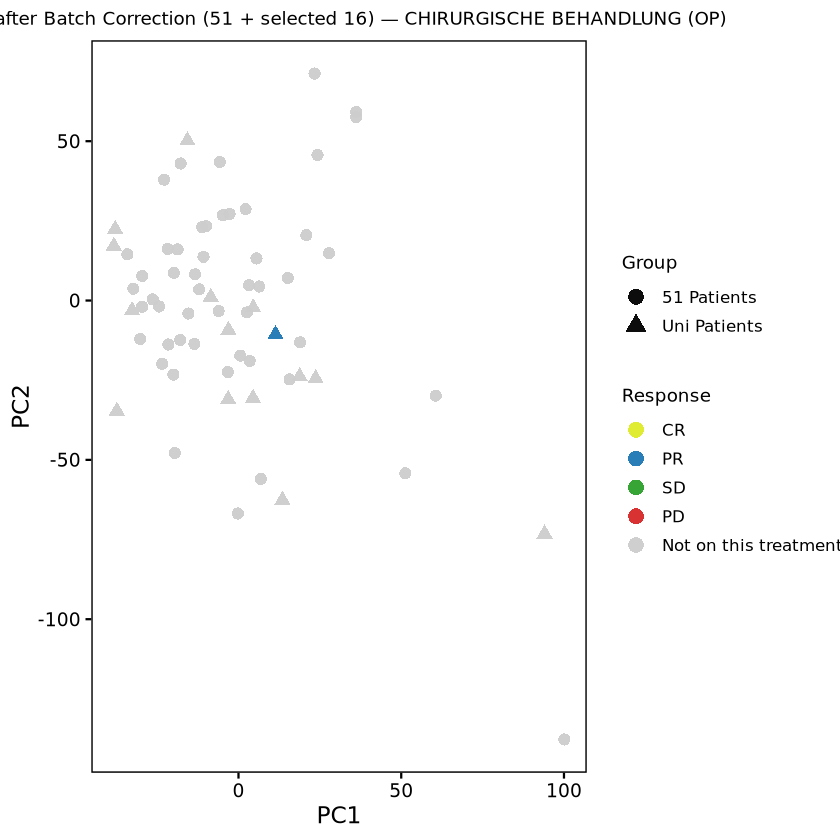

In [26]:
run_treatment_pca(
  TREAT_NAME     = "CHIRURGISCHE BEHANDLUNG (OP)",
  TREAT_PATTERNS = c("\\b(op|operation|chirurg|surgery)\\w*\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIOTHERAPIE + FOLFOX' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIOTHERAPIE + FOLFOX' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIOTHERAPIE + FOLFOX' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — RADIOTHERAPIE + FOLFOX' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA 

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   1   64 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    14    1


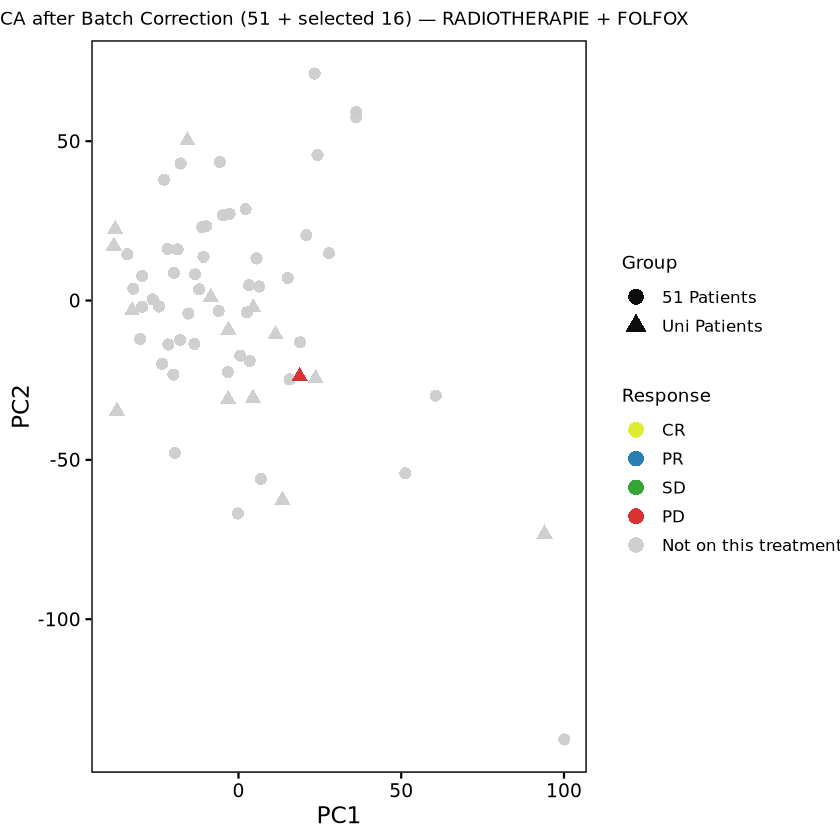

In [27]:
run_treatment_pca(
  TREAT_NAME     = "RADIOTHERAPIE + FOLFOX",
  TREAT_PATTERNS = c("\\b(radio|radiotherap|radiotherapie|rt)\\w*\\b", "\\bm?folfox\\w*\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AVASTIN' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AVASTIN' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AVASTIN' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFIRI + AVASTIN' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correcti

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
   5   60 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    10    5


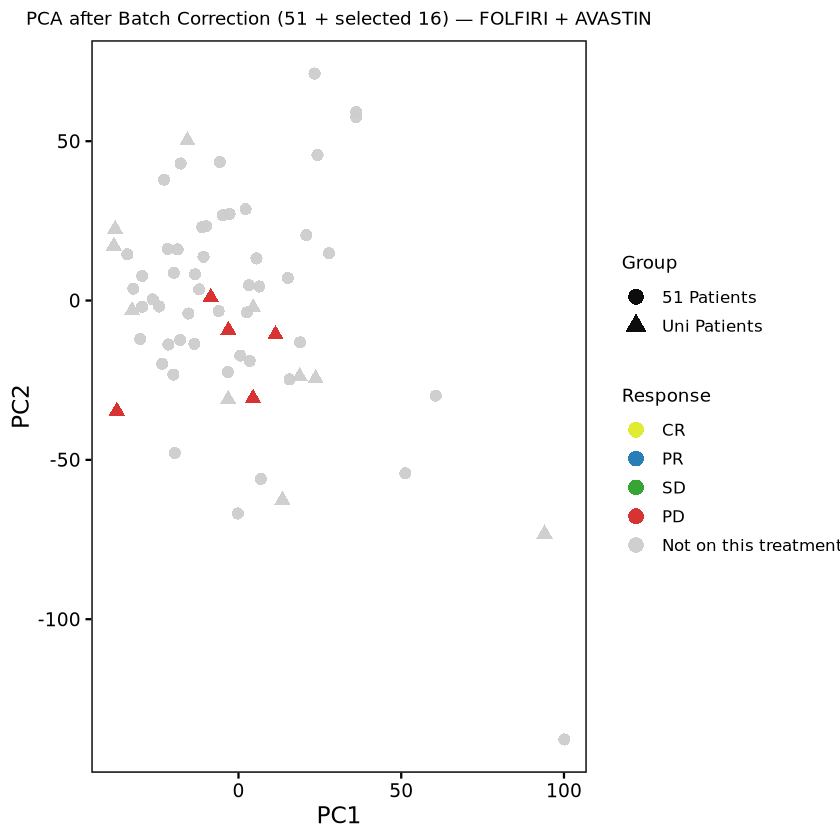

In [28]:
run_treatment_pca(
  TREAT_NAME     = "FOLFIRI + AVASTIN",
  TREAT_PATTERNS = c("\\bfolfiri\\w*\\b", "\\b(avastin|bevacizumab)\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — FOLFOX + AVASTIN' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (

51-sheet rows matching treatment: 0 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   SD <NA> 
   3    1   61 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     50    0
  Uni Patients    11    4


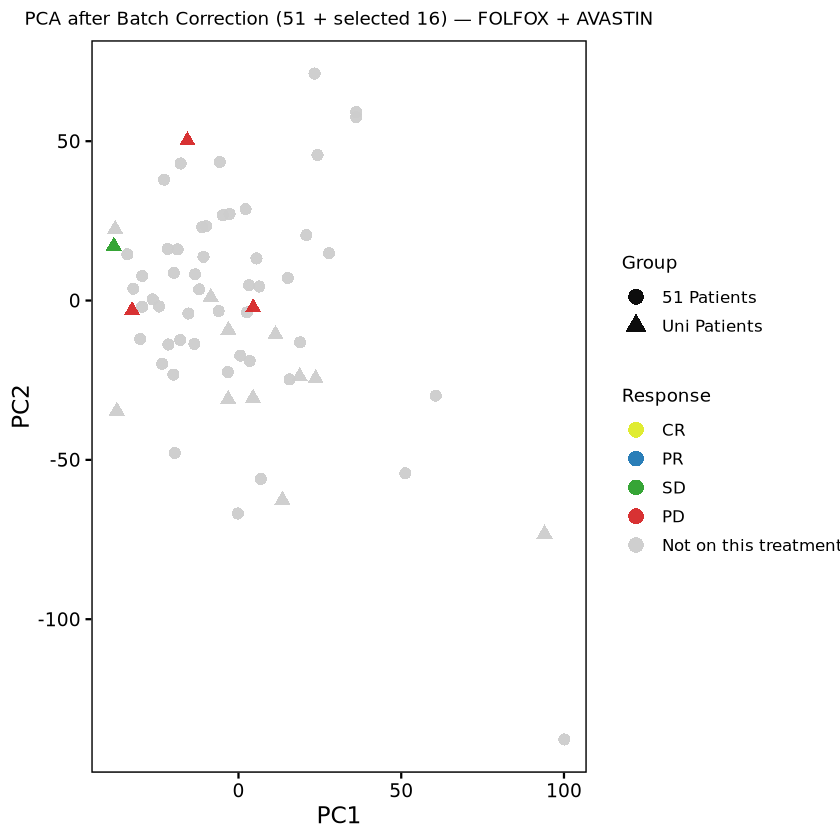

In [29]:
run_treatment_pca(
  TREAT_NAME     = "FOLFOX + AVASTIN",
  TREAT_PATTERNS = c("\\bm?folfox\\w*\\b", "\\b(avastin|bevacizumab)\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BKM120' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BKM120' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BKM120' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BKM120' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BKM120' in 'mbcsToSb

51-sheet rows matching treatment: 400 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   PR   SD <NA> 
  37    2    1   25 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     10   40
  Uni Patients    15    0


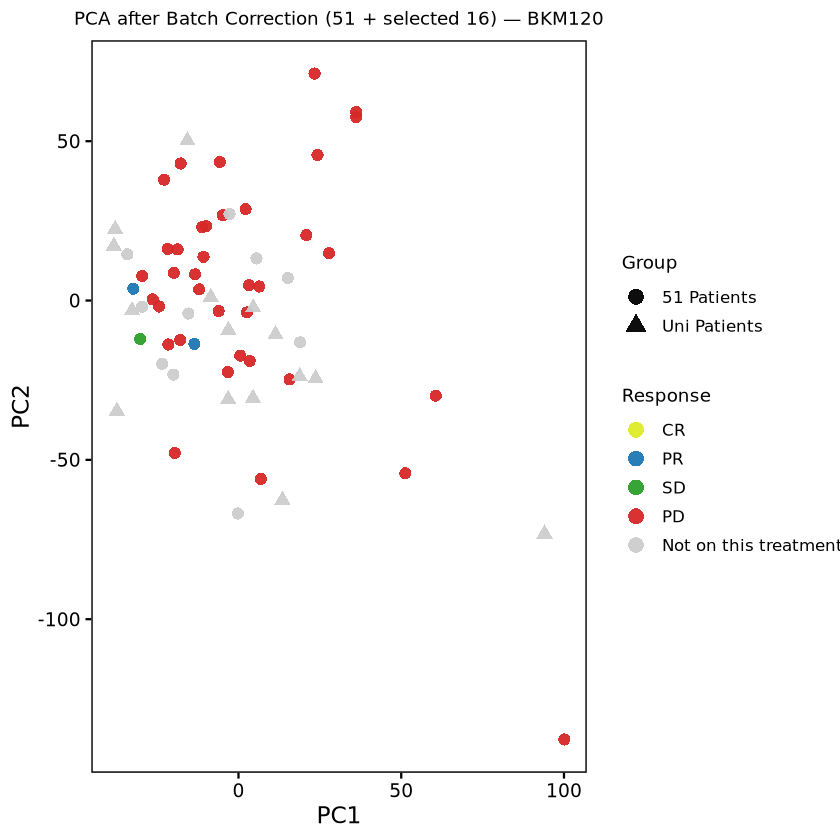

In [30]:
run_treatment_pca(
  TREAT_NAME     = "BKM120",
  TREAT_PATTERNS = c("\\bbkm\\s*120\\b|\\bbkm120\\b|\\bbuparlisib\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 5FU' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 5FU' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 5FU' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 5FU' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 5FU' in 'mbcsToSbcs': dot substi

51-sheet rows matching treatment: 43 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   PR   SD <NA> 
  37    1    4   23 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients      9   41
  Uni Patients    14    1


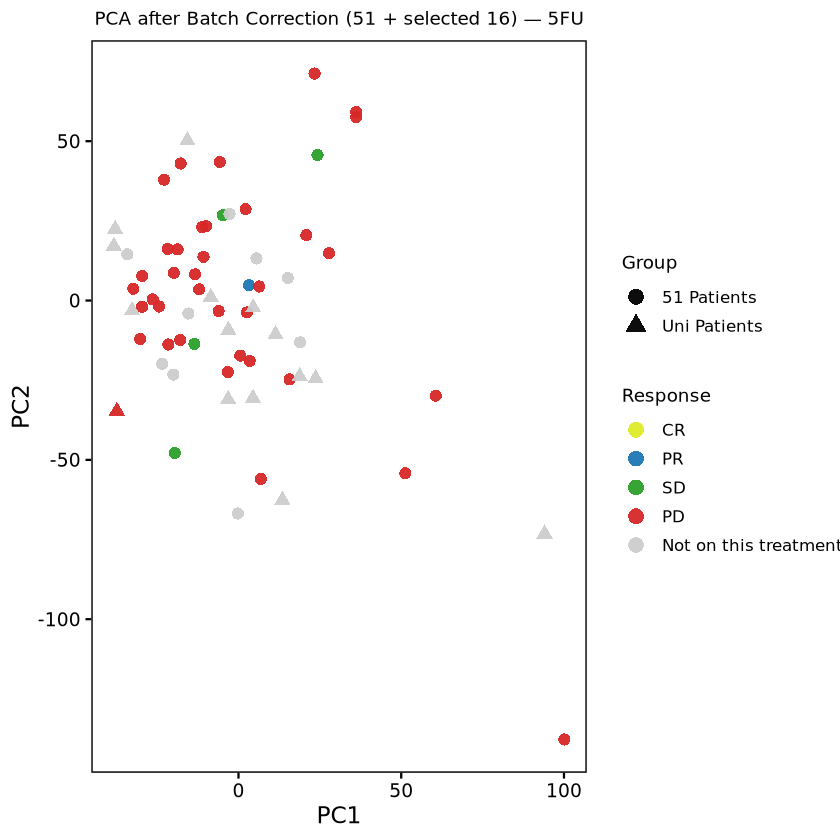

In [31]:
run_treatment_pca(
  TREAT_NAME     = "5FU",
  TREAT_PATTERNS = c("\\b5\\s*-?\\s*fu\\b|\\bfluorouracil\\b|\\b5\\s*-?\\s*fluorouracil\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — Binimetinib' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — Binimetinib' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — Binimetinib' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — Binimetinib' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 

51-sheet rows matching treatment: 575 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   PR   SD <NA> 
  29   11   10   15 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients      0   50
  Uni Patients    15    0


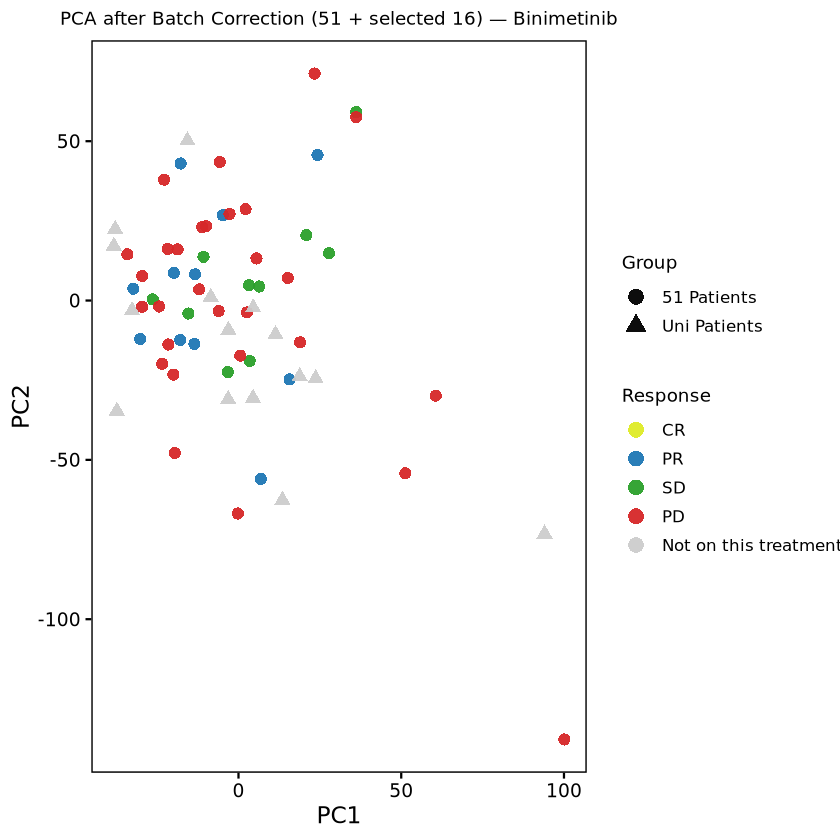

In [32]:
run_treatment_pca(
  TREAT_NAME     = "Binimetinib",
  TREAT_PATTERNS = c("\\bbinimetinib\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CGM097' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CGM097' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CGM097' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CGM097' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CGM097' in 'mbcsToSb

51-sheet rows matching treatment: 140 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
  37   28 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     13   37
  Uni Patients    15    0


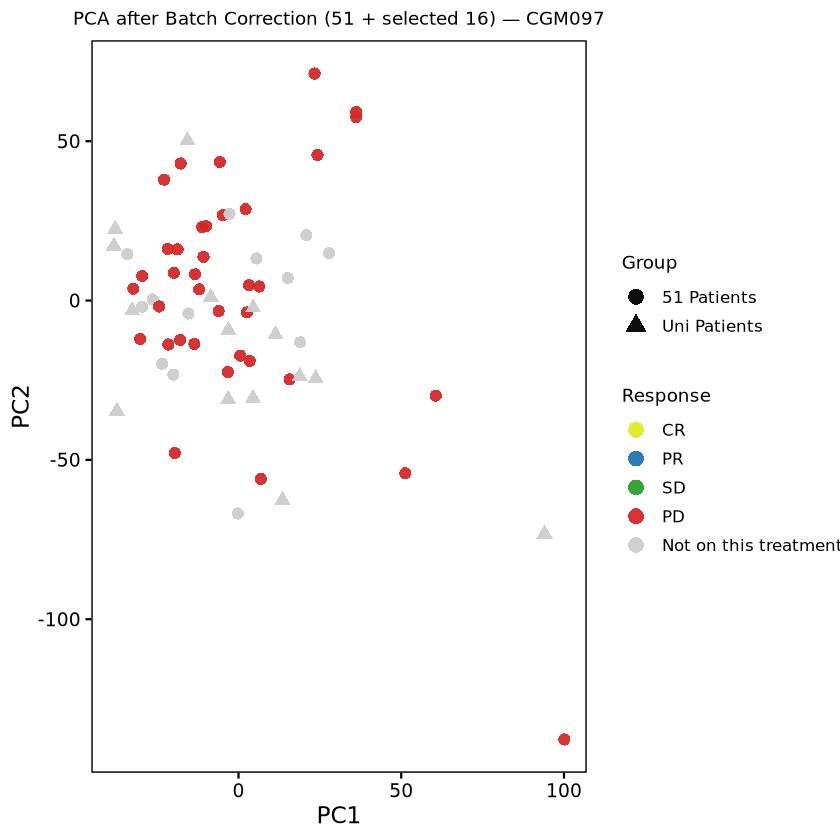

In [33]:
run_treatment_pca(
  TREAT_NAME     = "CGM097",
  TREAT_PATTERNS = c("\\bcgm097\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BYL719' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BYL719' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BYL719' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BYL719' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — BYL719' in 'mbcsToSb

51-sheet rows matching treatment: 715 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   SD <NA> 
  38    3   24 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients      9   41
  Uni Patients    15    0


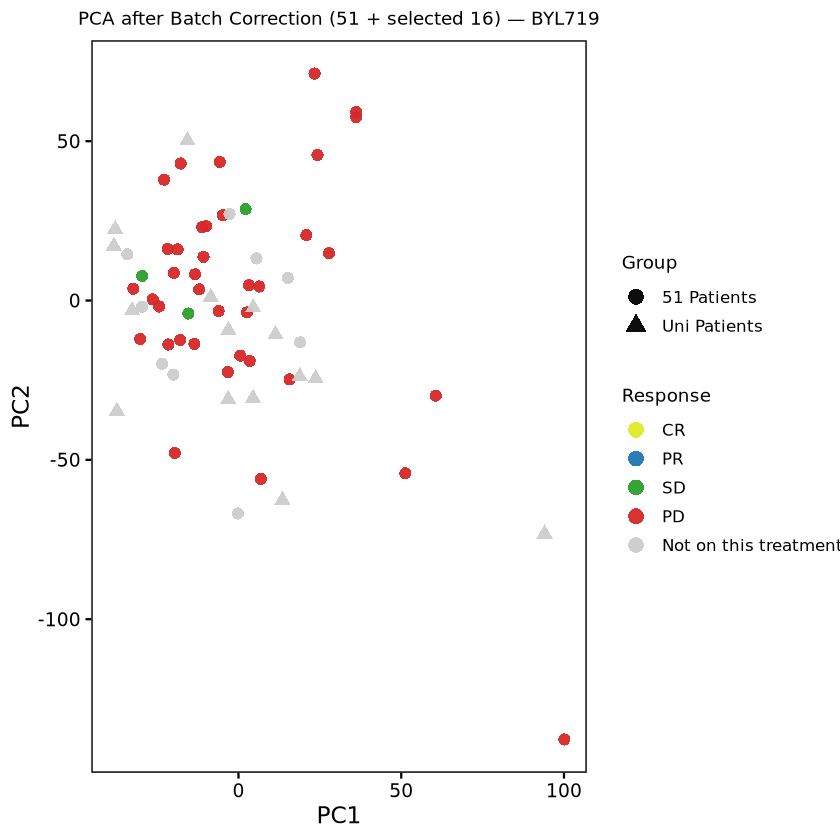

In [34]:
run_treatment_pca(
  TREAT_NAME     = "BYL719",
  TREAT_PATTERNS = c("\\bbyl719\\b|\\balpelisib\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CKX620' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CKX620' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CKX620' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CKX620' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CKX620' in 'mbcsToSb

51-sheet rows matching treatment: 70 
Colored counts (CR/PR/SD/PD) across both cohorts:

  CR   PD   SD <NA> 
   1   31    7   26 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     11   39
  Uni Patients    15    0


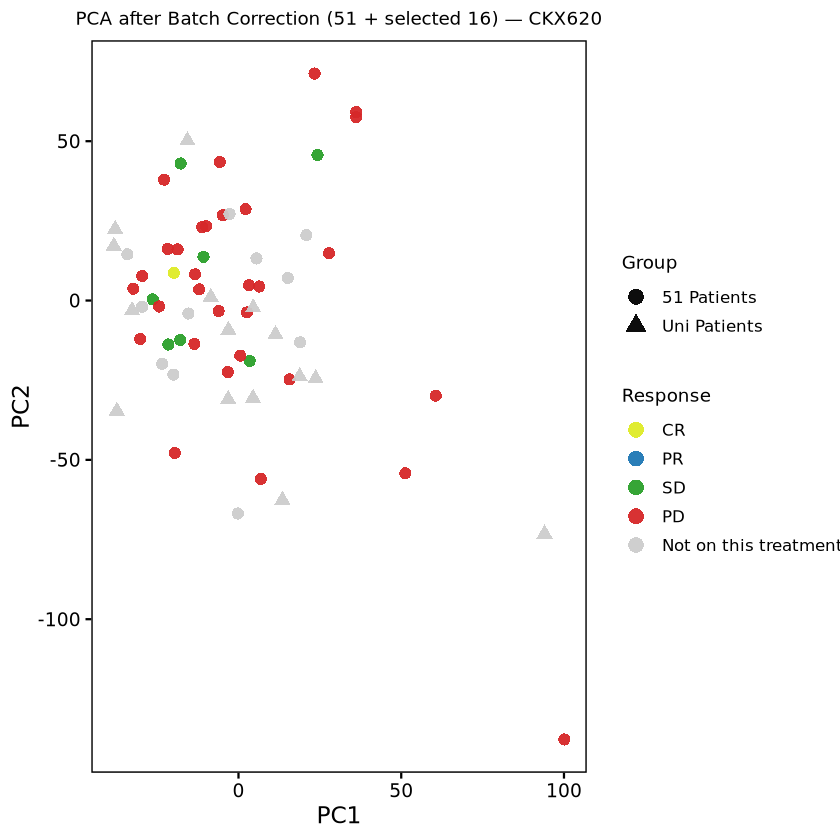

In [35]:

run_treatment_pca(
  TREAT_NAME     = "CKX620",
  TREAT_PATTERNS = c("\\bckx620\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CLR457' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CLR457' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CLR457' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CLR457' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — CLR457' in 'mbcsToSb

51-sheet rows matching treatment: 212 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   PR   SD <NA> 
  34    1    5   25 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     10   40
  Uni Patients    15    0


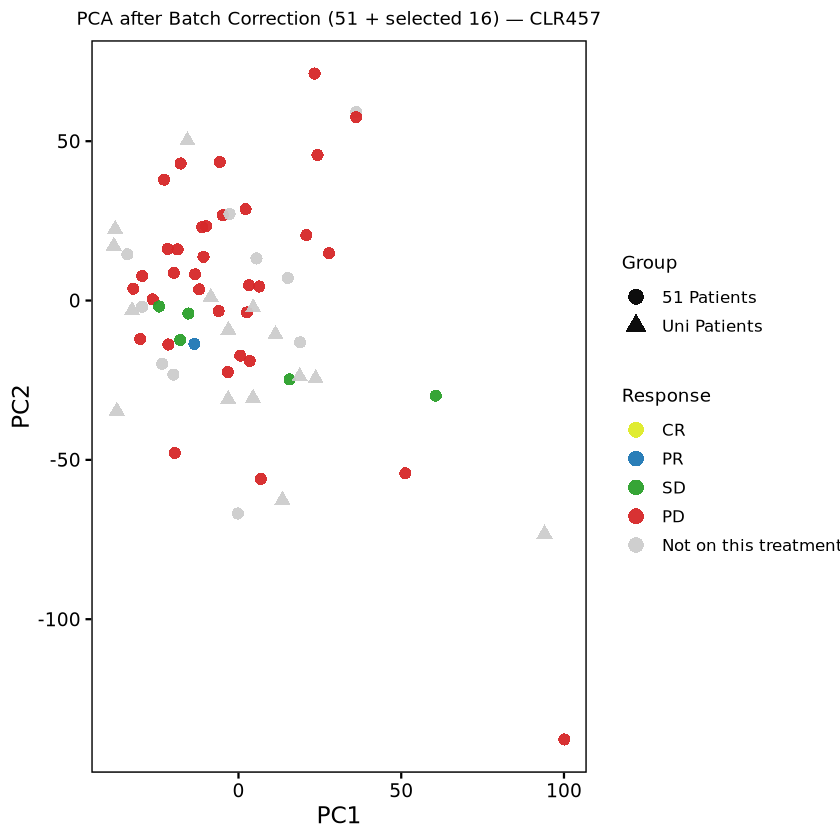

In [36]:
run_treatment_pca(
  TREAT_NAME     = "CLR457",
  TREAT_PATTERNS = c("\\bclr457\\b"),
  coords_sub     = coords_sub
)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — encorafenib' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — encorafenib' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — encorafenib' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — encorafenib' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — 

51-sheet rows matching treatment: 300 
Colored counts (CR/PR/SD/PD) across both cohorts:

  CR   PD   PR   SD <NA> 
   2   32    4    3   24 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients      9   41
  Uni Patients    15    0


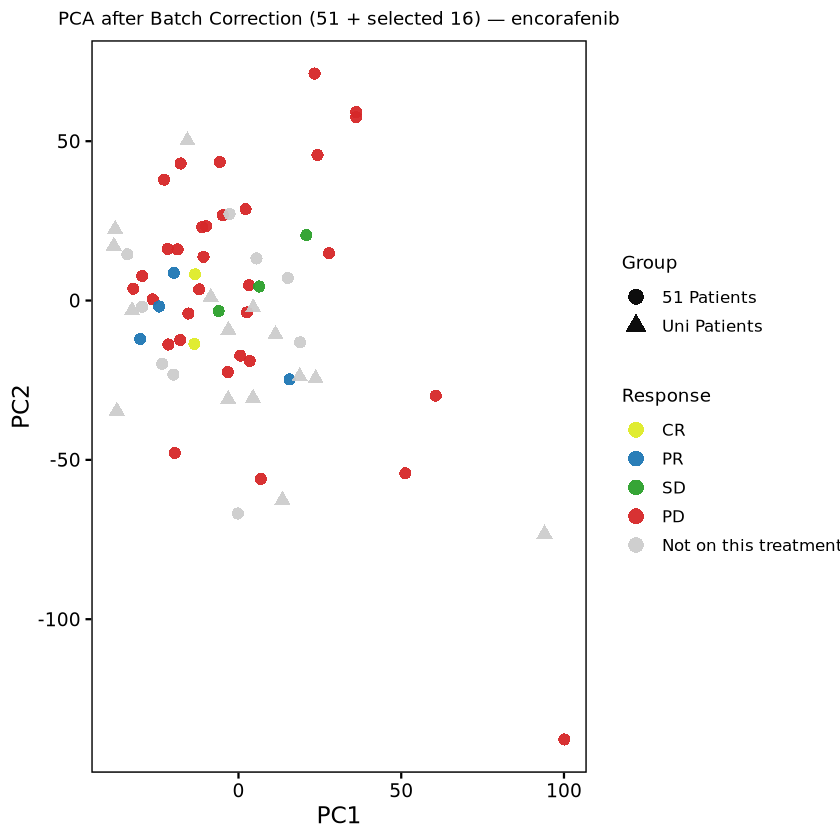

In [37]:

run_treatment_pca(
  TREAT_NAME     = "encorafenib",
  TREAT_PATTERNS = c("\\bencorafenib\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — HDM201' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — HDM201' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — HDM201' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — HDM201' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — HDM201' in 'mbcsToSb

51-sheet rows matching treatment: 191 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD <NA> 
  39   26 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     11   39
  Uni Patients    15    0


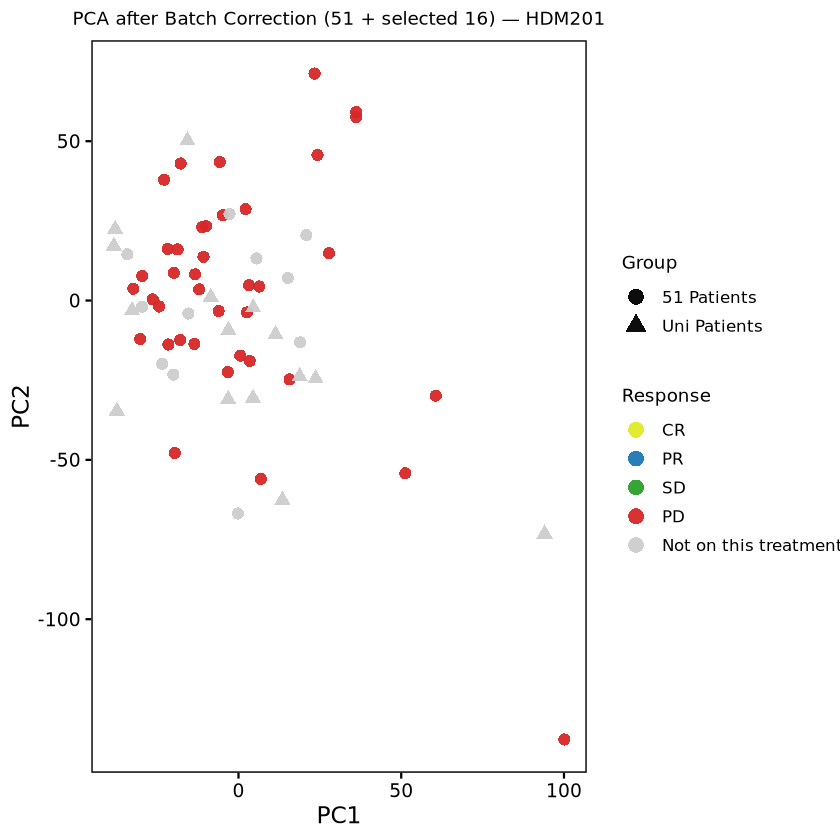

In [38]:

run_treatment_pca(
  TREAT_NAME     = "HDM201",
  TREAT_PATTERNS = c("\\bhdm201\\b"),
  coords_sub     = coords_sub
)


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LEE011' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LEE011' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LEE011' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LEE011' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LEE011' in 'mbcsToSb

51-sheet rows matching treatment: 433 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   PR   SD <NA> 
  37    1    3   24 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients      9   41
  Uni Patients    15    0


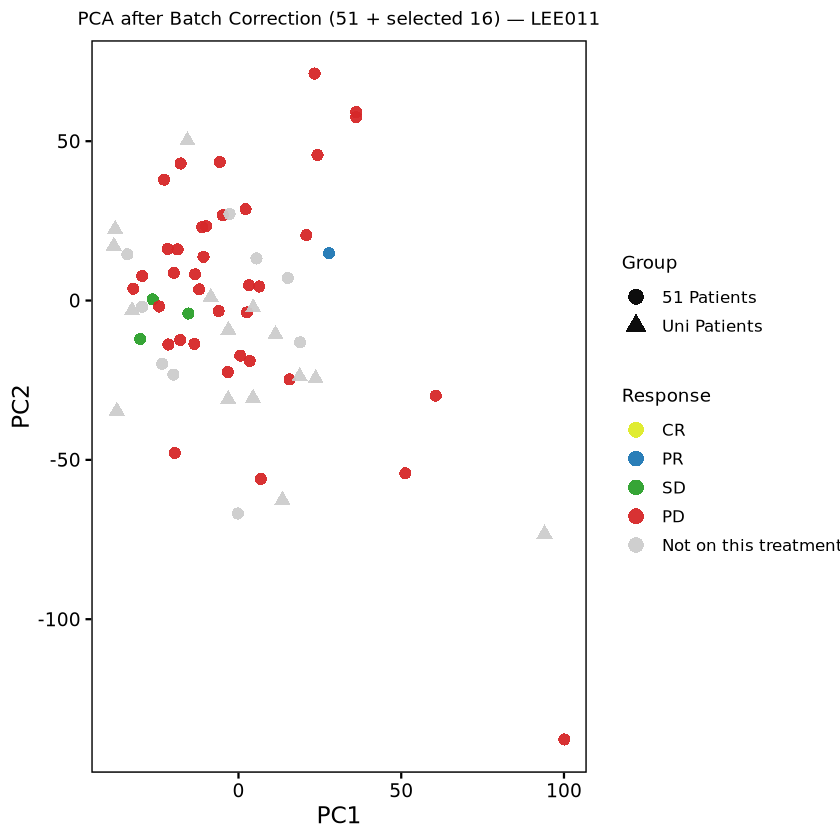

In [39]:
run_treatment_pca(
  TREAT_NAME     = "LEE011",
  TREAT_PATTERNS = c("\\blee011\\b|\\bribociclib\\b"),
  coords_sub     = coords_sub
)



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LKA136' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LKA136' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LKA136' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LKA136' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LKA136' in 'mbcsToSb

51-sheet rows matching treatment: 120 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   SD <NA> 
  38    1   26 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     11   39
  Uni Patients    15    0


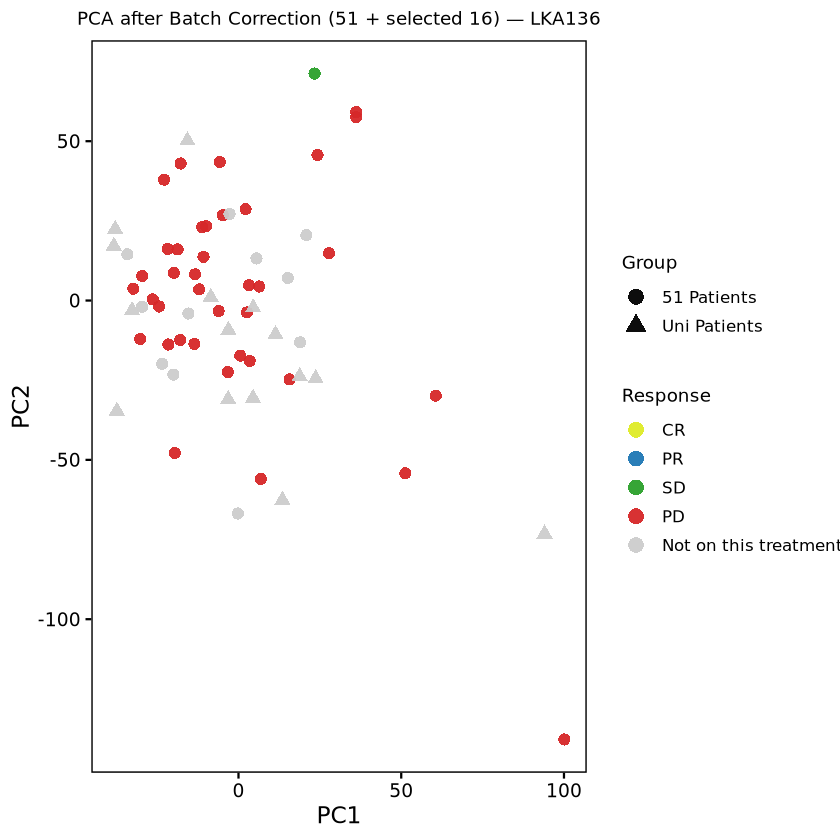

In [40]:

run_treatment_pca(
  TREAT_NAME     = "LKA136",
  TREAT_PATTERNS = c("\\blka136\\b"),
  coords_sub     = coords_sub
)



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LJC049' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LJC049' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LJC049' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LJC049' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'PCA after Batch Correction (51 + selected 16) — LJC049' in 'mbcsToSb

51-sheet rows matching treatment: 83 
Colored counts (CR/PR/SD/PD) across both cohorts:

  PD   PR   SD <NA> 
  33    2    5   25 

Colored (non-NA) by cohort:
              
set            FALSE TRUE
  51 Patients     10   40
  Uni Patients    15    0


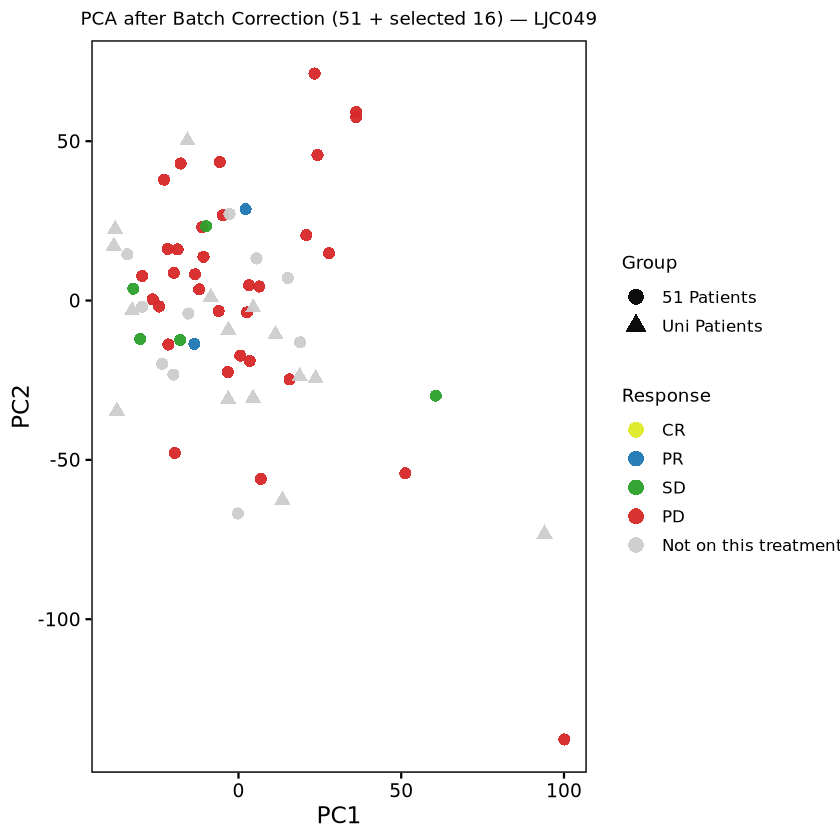

In [41]:

run_treatment_pca(
  TREAT_NAME     = "LJC049",
  TREAT_PATTERNS = c("\\bljc049\\b"),
  coords_sub     = coords_sub
)

In [42]:
########################################################
## FULL SCRIPT: Top-N best K per treatment + export colored PCA CSVs
########################################################

## =========================
## 0) Libraries
## =========================
suppressPackageStartupMessages({
  library(ggplot2)
})

## =========================
## 1) SETTINGS
## =========================
# Where to save the Top20 plot and the exported PCA CSVs
OUT_DIR <- "/mnt/lustre/home/nahnsen/nahfo470/mycode"
if (!dir.exists(OUT_DIR)) dir.create(OUT_DIR, recursive = TRUE)

# Choose your PCA input object:
# - coords or coords_sub must exist in your environment
df_in <- if (exists("coords")) coords else coords_sub

# IMPORTANT:
# Your df_in columns are: PC1, PC2, set, label
# The treatment condition column is therefore "set" (NOT "Treatment").
TREATMENT_COL <- "set"

## =========================
## 2) TOP-N "best per treatment" plot (KNN results)
## =========================
# Assumes you already built res_df with columns:
# Treatment, K, CV_Accuracy (and optionally others)
# If your res_df uses "set" instead of "Treatment", rename it before this block.

if (exists("res_df")) {

  if (!("Treatment" %in% colnames(res_df)) && ("set" %in% colnames(res_df))) {
    # If your results table uses 'set', rename to 'Treatment' for consistency
    res_df$Treatment <- res_df$set
  }

  stopifnot(all(c("Treatment", "K", "CV_Accuracy") %in% colnames(res_df)))

  # pick the single best row per Treatment (tie-break: higher accuracy, then smaller K)
  best_rows_idx <- unlist(lapply(split(seq_len(nrow(res_df)), res_df$Treatment), function(idx) {
    sub <- res_df[idx, , drop = FALSE]
    sub <- sub[order(-sub$CV_Accuracy, sub$K), , drop = FALSE]
    rownames(sub) <- NULL
    idx[match(1, seq_len(nrow(sub)))]  # placeholder, overwritten below
    # map back to original idx: pick the row in idx corresponding to best in sub
    idx[order(-res_df$CV_Accuracy[idx], res_df$K[idx])[1]]
  }))

  best_per_tx <- res_df[best_rows_idx, , drop = FALSE]
  best_per_tx <- best_per_tx[order(-best_per_tx$CV_Accuracy), , drop = FALSE]

  # top N (safe if fewer than 20)
  N <- min(20, nrow(best_per_tx))
  topn <- best_per_tx[seq_len(N), , drop = FALSE]

  cat("\nTop treatments by KNN accuracy:\n")
  print(topn)

  # plot: since we have ONE bar per treatment, no dodge needed
  p <- ggplot(topn, aes(x = reorder(Treatment, CV_Accuracy), y = CV_Accuracy, fill = factor(K))) +
    geom_col() +
    coord_flip() +
    labs(
      title = "KNN CV Accuracy by Treatment",
      subtitle = "Best K per treatment; 5-fold CV; PCs up to PC10",
      x = "Treatment",
      y = "Mean CV Accuracy",
      fill = "K"
    ) +
    theme_minimal(base_size = 13)

  print(p)

  ggsave(file.path(OUT_DIR, "KNN_Top20_Treatments.jpg"), plot = p,
         width = 9, height = 6, dpi = 300)
  message("📊 Plot saved to: ", file.path(OUT_DIR, "KNN_Top20_Treatments.jpg"))

} else {
  message("ℹ️ 'res_df' not found in the environment. Skipping Top20 KNN plot block.")
}

########################################################
## 3) Helper: make filenames clean
########################################################
treat_slug <- function(x) {
  s <- tolower(trimws(as.character(x)))
  s <- gsub("[\u2013\u2014]", "-", s)         # fancy dashes -> "-"
  s <- gsub("\\s*\\+\\s*", "_PLUS_", s)       # " + " -> "_PLUS_"
  s <- gsub("[^a-z0-9_-]+", "_", s)           # non-safe chars -> "_"
  s <- gsub("_+", "_", s)                     # collapse underscores
  s <- gsub("^_|_$", "", s)                   # trim underscores
  toupper(s)
}

########################################################
## 4) Export "colored PCA dataframe" for one treatment
########################################################
export_colored_pca <- function(df_all, treat, out_dir,
                               treatment_col = "set",
                               prefix = "PCA_batchcorrect_51plus16_") {
  if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

  if (!treatment_col %in% colnames(df_all)) {
    stop("Column '", treatment_col, "' not found in df_all. Available columns:\n",
         paste(colnames(df_all), collapse = ", "))
  }

  # robust string match (handles whitespace and fancy dashes)
  norm <- function(z) trimws(gsub("[\u2013\u2014]", "-", as.character(z)))

  df_full <- df_all
  df_full$SelectedTreatment <- treat
  df_full$IsSelected <- norm(df_full[[treatment_col]]) == norm(treat)
  df_full$ColorGroup <- ifelse(df_full$IsSelected, "SELECTED", "OTHER")

  out_csv <- file.path(out_dir, paste0(prefix, treat_slug(treat), "_colored.csv"))
  write.csv(df_full, out_csv, row.names = FALSE)

  n_sel <- sum(df_full$IsSelected, na.rm = TRUE)
  message("✅ Wrote: ", out_csv,
          " | rows: ", nrow(df_full),
          " | selected: ", n_sel)
  invisible(out_csv)
}

########################################################
## 5) Your treatments list
########################################################
treatments <- c(
  "5FU",
  "FOLFIRI + Avastin",
  "FOLFIRI + Aflibercept",
  "FOLFIRI + Panitumumab",
  "FOLFOX + Avastin",
  "FOLFOX + Panitumumab",
  "FOLFOX + Cetuximab",
  "FOLFOX (Exact 16UNI)",
  "FOLFOX + Avastin (Exact 16UNI)",
  "FOLFOX + Avastin (Exact 16UNI, second)",
  "FOLFOX + Panitumumab (Exact 16UNI)",
  "XELOX + Avastin",
  "Lonsurf (trifluridine/tipiracil)",
  "Lonsurf (Exact 16UNI)",
  "Lonsurf + Panitumumab (Exact 16UNI)",
  "Radiochemotherapy",
  "Radiotherapie + FOLFOX",
  "Chirurgischen Behandlung (OP)",
  "BYL719",
  "BYL719 + Binimetinib",
  "BYL719 + Cetuximab",
  "BYL719 + Cetuximab + Encorafenib",
  "BYL719 + LJM716",
  "BYL719 + Encorafenib",
  "Binimetinib",
  "BKM120",
  "BKM120 + LJC049",
  "CLR457",
  "CKX620",
  "CKX620 (Exact 16UNI)",
  "CGM097",
  "CGM097 (Exact 16UNI)",
  "HDM201",
  "LEE011",
  "LFW527 + Binimetinib",
  "LKA136",
  "LJC049",
  "LJC049 (Exact 16UNI)",
  "Cetuximab + Encorafenib"
)

########################################################
## 6) OPTIONAL: sanity checks before export
########################################################
cat("\nColumns in df_in:\n")
print(colnames(df_in))

cat("\nUnique values in df_in[[TREATMENT_COL]] (first 50):\n")
print(head(sort(unique(df_in[[TREATMENT_COL]])), 50))

missing <- setdiff(treatments, unique(df_in[[TREATMENT_COL]]))
if (length(missing) > 0) {
  message("\n⚠️ Treatments in your list that are NOT found in df_in[['", TREATMENT_COL, "']]:\n- ",
          paste(missing, collapse = "\n- "))
} else {
  message("\n✅ All treatments in your list exist in df_in[['", TREATMENT_COL, "']].")
}

########################################################
## 7) Export all treatments
########################################################
for (t in treatments) {
  export_colored_pca(df_in, t, OUT_DIR, treatment_col = TREATMENT_COL)
}

message("\nDone ✅")


ℹ️ 'res_df' not found in the environment. Skipping Top20 KNN plot block.




Columns in df_in:
[1] "PC1"   "PC2"   "set"   "label"

Unique values in df_in[[TREATMENT_COL]] (first 50):
[1] 51 Patients  Uni Patients
Levels: 51 Patients Uni Patients



⚠️ Treatments in your list that are NOT found in df_in[['set']]:
- 5FU
- FOLFIRI + Avastin
- FOLFIRI + Aflibercept
- FOLFIRI + Panitumumab
- FOLFOX + Avastin
- FOLFOX + Panitumumab
- FOLFOX + Cetuximab
- FOLFOX (Exact 16UNI)
- FOLFOX + Avastin (Exact 16UNI)
- FOLFOX + Avastin (Exact 16UNI, second)
- FOLFOX + Panitumumab (Exact 16UNI)
- XELOX + Avastin
- Lonsurf (trifluridine/tipiracil)
- Lonsurf (Exact 16UNI)
- Lonsurf + Panitumumab (Exact 16UNI)
- Radiochemotherapy
- Radiotherapie + FOLFOX
- Chirurgischen Behandlung (OP)
- BYL719
- BYL719 + Binimetinib
- BYL719 + Cetuximab
- BYL719 + Cetuximab + Encorafenib
- BYL719 + LJM716
- BYL719 + Encorafenib
- Binimetinib
- BKM120
- BKM120 + LJC049
- CLR457
- CKX620
- CKX620 (Exact 16UNI)
- CGM097
- CGM097 (Exact 16UNI)
- HDM201
- LEE011
- LFW527 + Binimetinib
- LKA136
- LJC049
- LJC049 (Exact 16UNI)
- Cetuximab + Encorafenib



✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_5FU_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFIRI_AVASTIN_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFIRI_AFLIBERCEPT_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFIRI_PANITUMUMAB_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFOX_AVASTIN_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFOX_PANITUMUMAB_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFOX_CETUXIMAB_colored.csv | rows: 85 | selected: 0

✅ Wrote: /mnt/lustre/home/nahnsen/nahfo470/mycode/PCA_batchcorrect_51plus16_FOLFOX_EXACT_16

Found colored files: 109 
Saved: /mnt/lustre/home/nahnsen/nahfo470/mycode/KNN_summary_from_run_treatment_pca.csv 


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 20 Treatments — KNN CV Accuracy (K=5 vs K=7)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 20 Treatments — KNN CV Accuracy (K=5 vs K=7)' in 'mbcsToSbcs': dot substituted for <80>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 20 Treatments — KNN CV Accuracy (K=5 vs K=7)' in 'mbcsToSbcs': dot substituted for <94>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 20 Treatments — KNN CV Accuracy (K=5 vs K=7)' in 'mbcsToSbcs': dot substituted for <e2>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'Top 20 Treatments — KNN CV Accuracy (K=5 vs K=7)' in 'mbcsToSbcs': dot substituted for <80>”

Saved plot: /mnt/lustre/home/nahnsen/nahfo470/mycode/KNN_Top20_Treatments_from_run_treatment_pca.jpg 


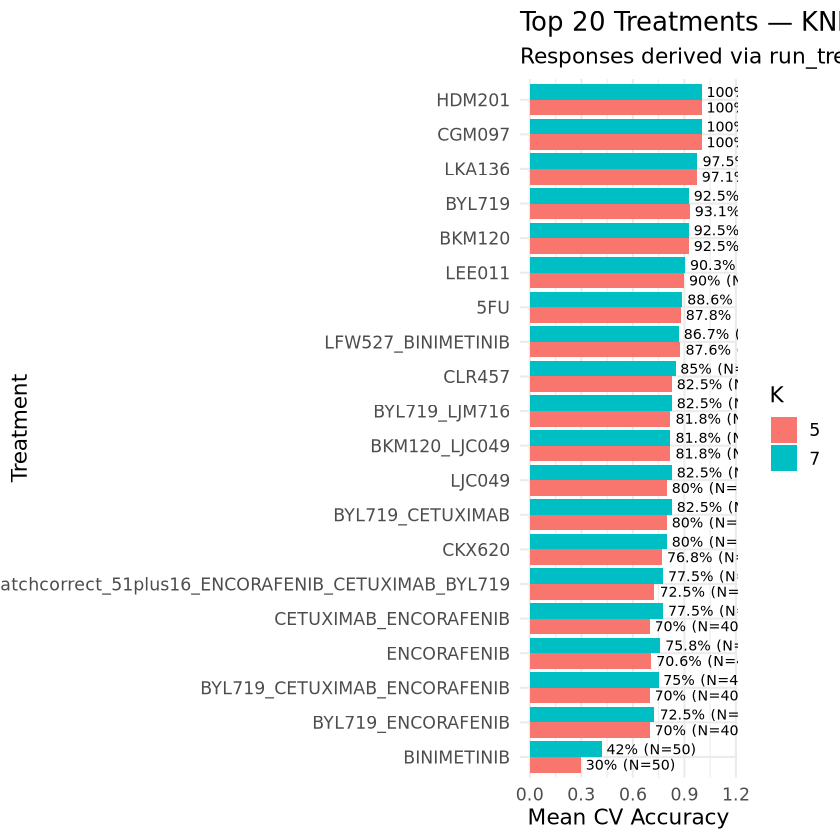

In [43]:
suppressPackageStartupMessages({
  library(readxl)
  library(dplyr)
  library(ggplot2)
  library(class)
})

OUT_DIR <- "/mnt/lustre/home/nahnsen/nahfo470/mycode"
set.seed(123)

# ---------------------------------------------------
# 0) You MUST have coords_sub in memory (PC1, PC2, set, sample/rownames)
# ---------------------------------------------------
stopifnot(exists("coords_sub"))
stopifnot(all(c("PC1","PC2","set") %in% names(coords_sub)))

# ---------------------------------------------------
# 1) Define your treatment panel (name + patterns)
#    Patterns are keywords: ALL must be present (case-insensitive)
# ---------------------------------------------------
treatment_defs <- list(
  list(name="5FU", patterns=c("5fu")),
  list(name="FOLFIRI + Avastin", patterns=c("folfiri","avastin")),
  list(name="FOLFIRI + Aflibercept", patterns=c("folfiri","aflibercept")),
  list(name="FOLFIRI + Panitumumab", patterns=c("folfiri","panitum")),
  list(name="FOLFOX + Avastin", patterns=c("folfox","avastin")),
  list(name="FOLFOX + Panitumumab", patterns=c("folfox","panitum")),
  list(name="FOLFOX + Cetuximab", patterns=c("folfox","cetux")),
  list(name="FOLFOX (Exact 16UNI)", patterns=c("folfox")),               # adjust if needed
  list(name="XELOX + Avastin", patterns=c("xelox","avastin")),
  list(name="Lonsurf", patterns=c("lonsurf")),
  list(name="Radiochemotherapy", patterns=c("radio","chemo")),
  list(name="Radiotherapie + FOLFOX", patterns=c("radio","folfox")),
  list(name="Chirurgischen Behandlung (OP)", patterns=c("op")),

  list(name="BYL719", patterns=c("byl719")),
  list(name="BYL719 + Binimetinib", patterns=c("byl719","binimet")),
  list(name="BYL719 + Cetuximab", patterns=c("byl719","cetux")),
  list(name="BYL719 + Cetuximab + Encorafenib", patterns=c("byl719","cetux","encoraf")),
  list(name="BYL719 + LJM716", patterns=c("byl719","ljm716")),
  list(name="BYL719 + Encorafenib", patterns=c("byl719","encoraf")),
  list(name="Binimetinib", patterns=c("binimet")),
  list(name="BKM120", patterns=c("bkm120")),
  list(name="BKM120 + LJC049", patterns=c("bkm120","ljc049")),
  list(name="CLR457", patterns=c("clr457")),
  list(name="CKX620", patterns=c("ckx620")),
  list(name="CGM097", patterns=c("cgm097")),
  list(name="HDM201", patterns=c("hdm201")),
  list(name="LEE011", patterns=c("lee011")),
  list(name="LFW527 + Binimetinib", patterns=c("lfw527","binimet")),
  list(name="LKA136", patterns=c("lka136")),
  list(name="LJC049", patterns=c("ljc049")),
  list(name="Cetuximab + Encorafenib", patterns=c("cetux","encoraf"))
)

# ---------------------------------------------------
# 2) Wrapper: run your existing function and collect CSV paths
#    (assumes run_treatment_pca() is already defined exactly as you pasted)
# ---------------------------------------------------
stopifnot(exists("run_treatment_pca"))



colored_files <- list.files(
  OUT_DIR,
  pattern = "^PCA_.*_colored\\.csv$",
  full.names = TRUE
)

cat("Found colored files:", length(colored_files), "\n")

# ---------------------------------------------------
# 3) KNN CV helper
# ---------------------------------------------------
cv_knn <- function(X, y, k = 5, folds = 5) {
  n <- nrow(X)
  if (n < folds) stop("Not enough rows for CV.")
  fold_ids <- sample(rep(1:folds, length.out = n))
  acc <- numeric(folds)
  for (f in seq_len(folds)) {
    test_idx  <- which(fold_ids == f)
    train_idx <- setdiff(seq_len(n), test_idx)
    pred <- class::knn(
      train = X[train_idx, , drop = FALSE],
      test  = X[test_idx,  , drop = FALSE],
      cl    = y[train_idx],
      k     = k
    )
    acc[f] <- mean(pred == y[test_idx])
  }
  mean(acc)
}

# ---------------------------------------------------
# 4) Scan the generated PCA_*_colored.csv files and compute KNN
# ---------------------------------------------------
results <- list()

for (f in colored_files) {
  df <- tryCatch(read.csv(f, stringsAsFactors = FALSE), error = function(e) NULL)
  if (is.null(df)) next
  if (!("ResponseLegend" %in% names(df))) next

  df_lab <- df[df$ResponseLegend %in% c("CR","PR","SD","PD"), , drop = FALSE]
  if (nrow(df_lab) < 8) next

  pc_cols <- grep("^PC[0-9]+$", names(df_lab), value = TRUE)
  want <- intersect(paste0("PC", 1:10), pc_cols)
  if (length(want) < 2) want <- intersect(paste0("PC", 1:2), pc_cols)
  if (length(want) < 2) next

  X <- scale(as.matrix(df_lab[, want, drop = FALSE]))
  y <- factor(df_lab$ResponseLegend, levels = c("CR","PR","SD","PD"))

  treat <- sub("^PCA_", "", sub("_colored\\.csv$", "", basename(f)))

  for (k in c(5, 7)) {
    acc <- cv_knn(X, y, k = k, folds = 5)
    results[[length(results) + 1]] <- data.frame(
      Treatment   = treat,
      K           = k,
      CV_Accuracy = acc,
      N_labeled   = nrow(df_lab),
      PCs_used    = paste(want, collapse = ","),
      stringsAsFactors = FALSE
    )
  }
}

if (!length(results)) stop("No valid KNN results computed (likely too few labeled per treatment).")
res_df <- do.call(rbind, results)

write.csv(res_df, file.path(OUT_DIR, "KNN_summary_from_run_treatment_pca.csv"), row.names = FALSE)
cat("Saved:", file.path(OUT_DIR, "KNN_summary_from_run_treatment_pca.csv"), "\n")

# ---------------------------------------------------
# 5) Top 20 plot (K comparison)
# ---------------------------------------------------
TOP_N <- 20

ranked <- res_df %>%
  group_by(Treatment) %>%
  summarise(BestAcc = max(CV_Accuracy, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(BestAcc)) %>%
  slice_head(n = TOP_N)

plot_df <- res_df %>%
  semi_join(ranked, by = "Treatment") %>%
  mutate(K = factor(K), Percent = 100 * CV_Accuracy)

p <- ggplot(plot_df,
            aes(x = reorder(Treatment, CV_Accuracy),
                y = CV_Accuracy,
                fill = K)) +
  geom_col(position = position_dodge(width = 0.9)) +
  coord_flip() +
  geom_text(aes(label = paste0(round(Percent, 1), "% (N=", N_labeled, ")")),
            position = position_dodge(width = 0.9),
            hjust = -0.05, size = 3) +
  ylim(0, max(plot_df$CV_Accuracy, na.rm = TRUE) * 1.15) +
  labs(
    title = paste0("Top ", min(TOP_N, n_distinct(plot_df$Treatment)),
                   " Treatments — KNN CV Accuracy (K=5 vs K=7)"),
    subtitle = "Responses derived via run_treatment_pca(); 5-fold CV",
    x = "Treatment",
    y = "Mean CV Accuracy",
    fill = "K"
  ) +
  theme_minimal(base_size = 13)

print(p)

out_plot <- file.path(OUT_DIR, "KNN_Top20_Treatments_from_run_treatment_pca.jpg")
ggsave(out_plot, plot = p, width = 10, height = 7, dpi = 300)
cat("Saved plot:", out_plot, "\n")
